# SINGLE CELL RNA SEQUENCING ANALYSIS - PART II

#### Created by: Holly Vose
#### Last Modified: 4/2/2026

This notebook is the second notebook in the analysis pipeline of single cell RNA sequencing. 

The prerequisite assumption is that there is an exported AnnData object in h5ad format to analyze. Technically this analysis can be done in the same notebook as the initial analysis, but loading the exported object takes significantly less resources than doing all analyses in the same notebook.

## CONTENTS:
### 1. Loading and Setup
        + Imports
        + Load Exported Data
        + Category Definition
        + Clustering Resolutions
        + Load Color Palettes
### 2. Analysis Methods
#### GENE ANALYSIS
        + Getting all genes present in the data
        + Finding gene expression across a cluster
        + Dotplot of most differentially expressed genes
#### PLOTTING
        + UMAP Plotting
        + Looping through a Gene List
        + Dotplots and Customization
        + Matrixplots
#### PATHWAY ANALYSIS
        + Gene Set Enrichment Analysis (GSEA) using gseapy
        + Over-Representation Analysis (ORA)
        + ORA looping
#### CLUSTER DEFINITIONS
        + Defining and Mapping Cluster Names
        + Differential Expression
#### MISCELLANEOUS

# **1.  LOADING AND SETUP**

The next few steps will set up our analysis environment by:
- Loading our exported h5ad file from Part I
- Adding/redefining columns as needed
- Loading in our color/colormap constants for visualizations

#### STEP 1: Imports

Load the code block below first to import all of our necessary libraries.

In [1]:
import re
import os
import pprint
import warnings
import scanpy as sc
import anndata as ad
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import gprofiler
import gseapy as gp
from gseapy import Biomart
import harmonypy as hm

warnings.filterwarnings('ignore')
sns.set_style("ticks")

#### STEP 2: Loading Exported Data

From Part 1 of this analysis, we should have a compressed file that ends in `.h5ad`. This is a file that is specifically compatible with scanpy and the requisite single cell analyses for this notebook.

In [2]:
#STEP 2: LOAD EXPORTED DATA

#adata_diet_filtered = sc.read_h5ad("adata_filtered_03252026.h5ad")
#adata_cd3_filtered = sc.read_h5ad("/projects/hvose@xsede.org/adata_filtered_files/adata_cd3_filtered_04062026.h5ad")
#adata_vg_filtered = sc.read_h5ad("/projects/hvose@xsede.org/adata_filtered_files/adata_filtered_04062026.h5ad")
#adata_filtered = sc.read_h5ad("/projects/hvose@xsede.org/adata_filtered_files/adata_filtered_1032025.h5ad")
adata_filtered = sc.read_h5ad("/scratch/alpine/hvose@xsede.org/viralogue-pipelines/scRNA-seq-pipeline/adata_live_refiltered_20260507.h5ad")

#### STEP 2.5: Defining New Categories (OPTIONAL)

The general format for defining new categories:

`adata_filtered.obs.loc[adata_filtered.obs[<reference category>] == <reference group>, <new category>] = <new value>`

For example, let's say my data already has a category called "infection_type" with the flags "infected" and "uninfected". Now, let's say I wanted to add a new category called "timeframe" where all of my infected samples are "5DPI". To do this, I would type:

`adata_filtered.obs.loc[adata_filtered.obs["infection_type"] == "infected", "timeframe"] = "5DPI"`

Under the hood, we are calling the subset of our data where the "infection_type" of our cells is equal to "infected". We then assign the value of "5DPI" to our new category "timeframe" for this subset of cells. All cells outside of thsi subset have a blank value for the "timeframe" category.

In [4]:
#OPTIONAL: in case the original h5ad data is labeled poorly
adata_filtered.obs.loc[adata_filtered.obs["i_type"] == "infected", "group"] = "5DPI"
adata_filtered.obs.loc[adata_filtered.obs["i_type"] == "uninfected", "group"] = "Mock"

In [3]:
#STEP 4: Generate QC metrics for our "MHV-Y" gene and our mitochondrial counts
adata_filtered.var["mt"] = adata_filtered.var_names.str.startswith("mt-")

sc.pp.calculate_qc_metrics(
    adata_filtered, qc_vars=["mt"], inplace=True, log1p=True
)

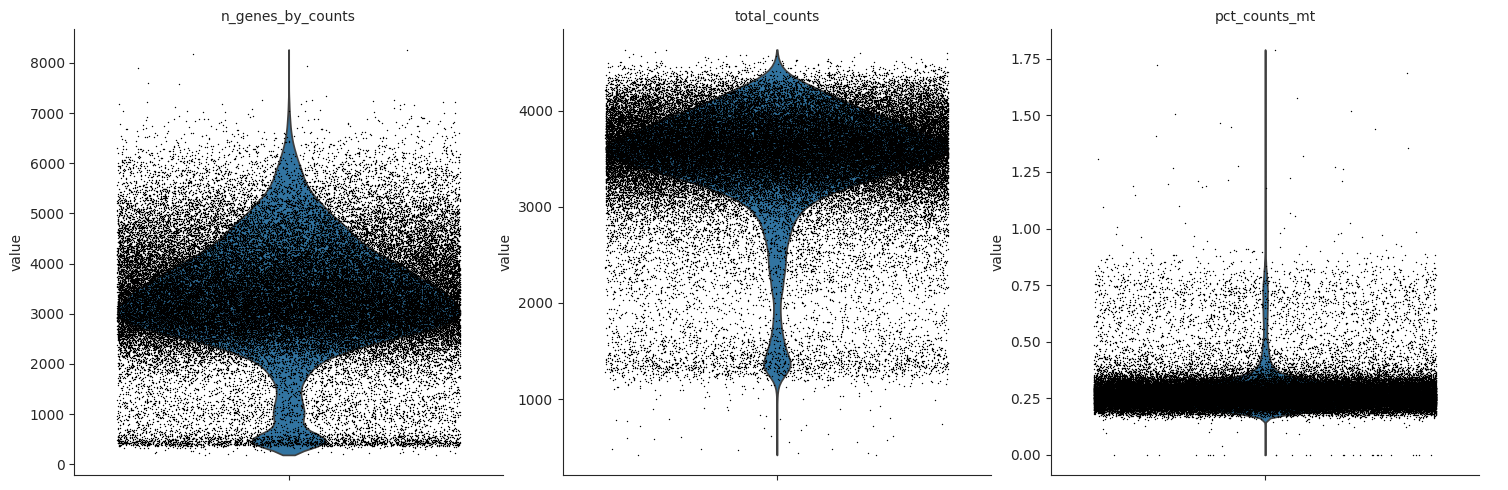

(-5.0, 10000.0)

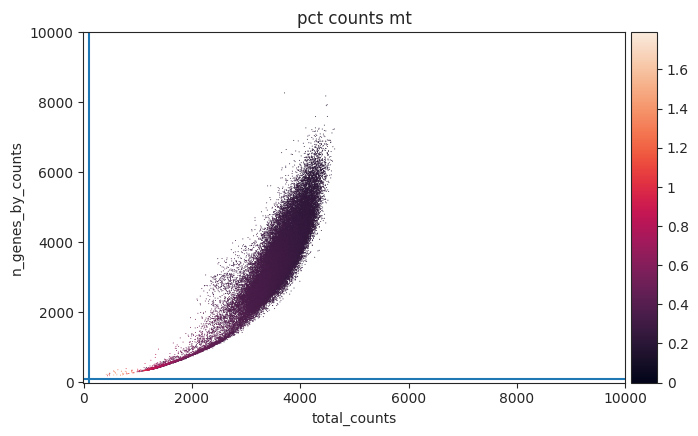

In [5]:
#STEP 4.5: Visualizing the generated QC metrics. Note that if other columns are specified, their specific
#counts will be labeled as pct_counts_[column name]
sc.pl.violin(
    adata_filtered,
    ["n_genes_by_counts", "total_counts","pct_counts_mt"],
    jitter=0.4,
    multi_panel=True,
)

#sc.pl.scatter(adata, "total_counts", "n_genes_by_counts", color="pct_counts_mhvy")
ax = sc.pl.scatter(adata_filtered, "total_counts", "n_genes_by_counts",color="pct_counts_mt",show=False)
ax.axhline(y=100)
ax.axvline(x=100)
ax.set_xlim(-5,10000)
ax.set_ylim(-5,10000)

In [10]:
#STEP 5: Filtering for just MHV-Y positive barcodes (or getting rid of cells with too high of a mitochondrial count)
adata_mid_filter = adata_filtered[adata_filtered.obs['pct_counts_mt']<5]

#If just cell barcodes are desired, you can add .obs_names to the end of the above statement.

#For context in the next section, we will print the dimensions of our current object.
adata_mid_filter.shape

(115584, 25606)

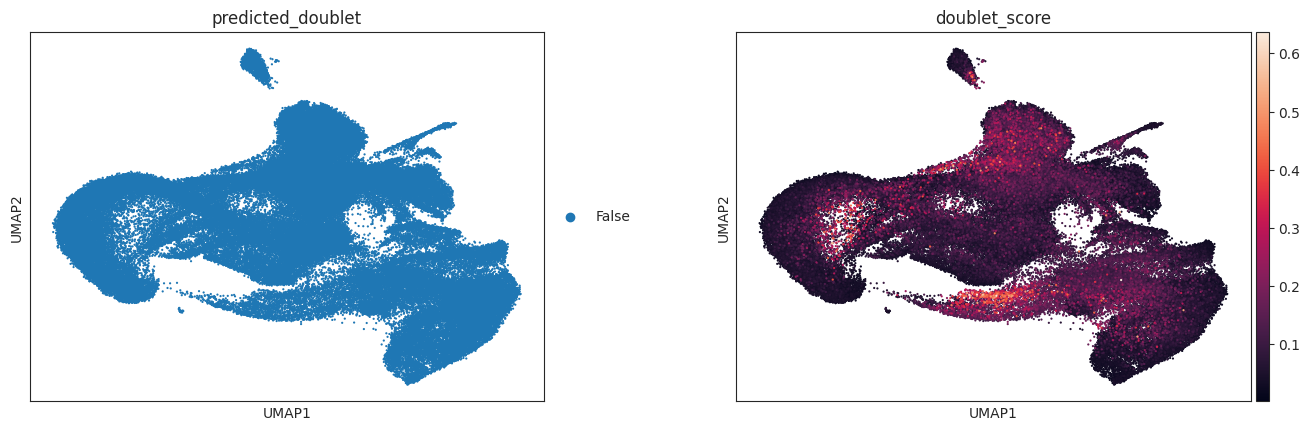

In [12]:
sc.pl.umap(
    adata_mid_filter,
    color= ["predicted_doublet", "doublet_score"],
    wspace=0.25,
    size=10,
)

In [13]:
actual_adata_filtered = adata_mid_filter[~adata_mid_filter.obs['predicted_doublet'] > 0.3].copy()

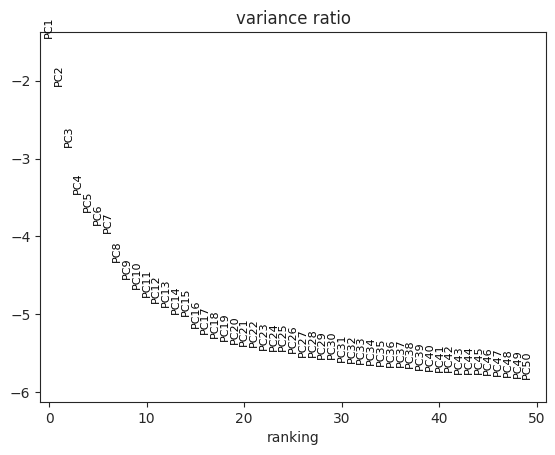

In [14]:
#STEP 17: Rerun our PCA to generate new principal components for the clustering
#sc.pp.pca(adata_filtered)
sc.pp.pca(actual_adata_filtered)
sc.pl.pca_variance_ratio(actual_adata_filtered, n_pcs=50, log=True)

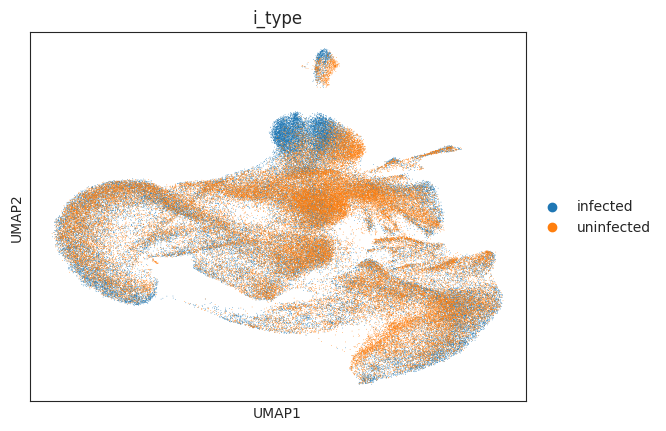

In [17]:
#STEP 18: Rerun all of our clustering on the new, filtered dataset
sc.pp.neighbors(actual_adata_filtered,n_pcs=15)
sc.tl.umap(actual_adata_filtered)
sc.tl.leiden(actual_adata_filtered, flavor="igraph", n_iterations=10)
sc.pl.umap(actual_adata_filtered, color="i_type")

In [21]:
# Get PCs from the AnnData object
pcs = actual_adata_filtered.obsm['X_pca']
print(pcs.shape)  # (n_cells, n_pcs)

# Run Harmony on the PCA embedding
harmony_out = hm.run_harmony(pcs, actual_adata_filtered.obs, "i_type")

print("finished harmony")

# Store corrected PCs back in the AnnData object
actual_adata_filtered.obsm['X_pca_harmony'] = harmony_out.Z_corr


(115584, 50)


2026-04-23 17:49:10,877 - harmonypy - INFO - Running Harmony (PyTorch on cpu)
2026-04-23 17:49:10,878 - harmonypy - INFO -   Parameters:
2026-04-23 17:49:10,878 - harmonypy - INFO -     max_iter_harmony: 10
2026-04-23 17:49:10,879 - harmonypy - INFO -     max_iter_kmeans: 20
2026-04-23 17:49:10,879 - harmonypy - INFO -     epsilon_cluster: 1e-05
2026-04-23 17:49:10,879 - harmonypy - INFO -     epsilon_harmony: 0.0001
2026-04-23 17:49:10,879 - harmonypy - INFO -     nclust: 100
2026-04-23 17:49:10,880 - harmonypy - INFO -     block_size: 0.05
2026-04-23 17:49:10,880 - harmonypy - INFO -     lamb: [1. 1.]
2026-04-23 17:49:10,881 - harmonypy - INFO -     theta: [2. 2.]
2026-04-23 17:49:10,881 - harmonypy - INFO -     sigma: [0.1 0.1 0.1 0.1 0.1]...
2026-04-23 17:49:10,881 - harmonypy - INFO -     verbose: True
2026-04-23 17:49:10,881 - harmonypy - INFO -     random_state: 0
2026-04-23 17:49:10,882 - harmonypy - INFO -   Data: 50 PCs × 115584 cells
2026-04-23 17:49:10,882 - harmonypy - INF

finished harmony


In [22]:
# Use harmonized PCs for downstream analysis
sc.pp.neighbors(actual_adata_filtered, use_rep='X_pca_harmony')
sc.tl.umap(actual_adata_filtered)
sc.tl.leiden(actual_adata_filtered)

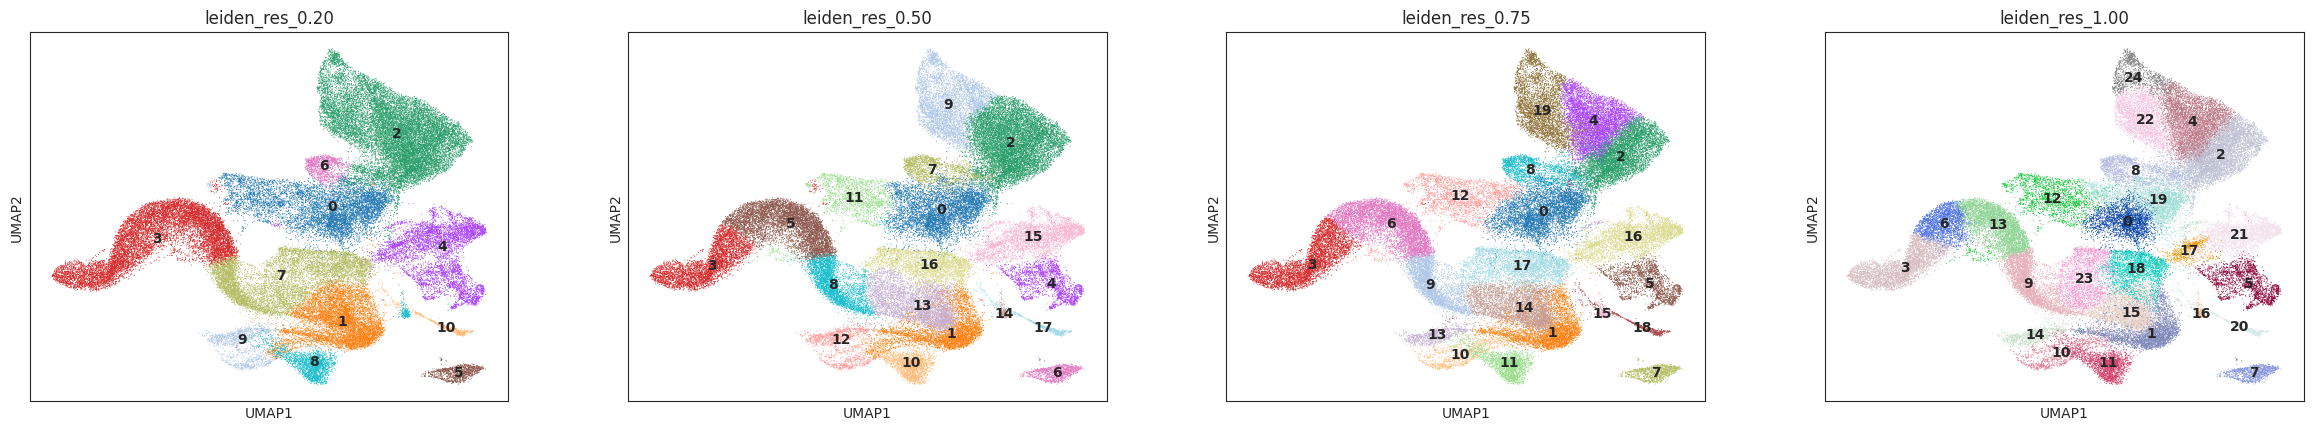

In [6]:
# STEP 3: GENERATE DIFFERENT RESOLUTIONS OF CLUSTERING

for res in [0.2, 0.5, 0.75, 1]:
    sc.tl.leiden(adata_filtered, key_added=f"leiden_res_{res:4.2f}", resolution=res, flavor="igraph")

sc.pl.umap(
    adata_filtered,
    color=["leiden_res_0.20", "leiden_res_0.50", "leiden_res_0.75","leiden_res_1.00"],
    legend_loc="on data",
) 

In [24]:
actual_adata_filtered.write_h5ad("20260423_live_recluster.h5ad")

#### STEP 3: Generating Clustering Resolutions
A **higher** resolution means the data will be more granular. This means more clusters, and less cells per cluster.

A **lower** resolution means the data will be more clumped. This means less clusters, and more cells per cluster.

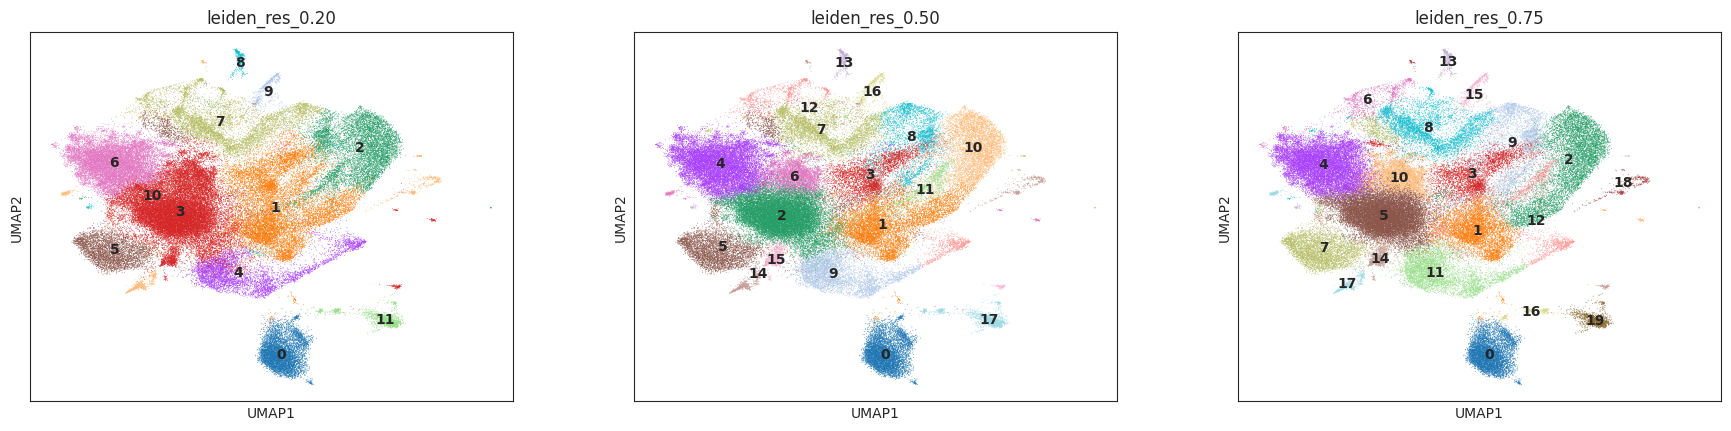

In [3]:
# STEP 3: GENERATE DIFFERENT RESOLUTIONS OF CLUSTERING

for res in [0.2, 0.5, 0.75]:
    sc.tl.leiden(adata_vg_filtered, key_added=f"leiden_res_{res:4.2f}", resolution=res, flavor="igraph")

sc.pl.umap(
    adata_vg_filtered,
    color=["leiden_res_0.20", "leiden_res_0.50", "leiden_res_0.75"],
    legend_loc="on data",
)

In [ ]:
# STEP 3: GENERATE DIFFERENT RESOLUTIONS OF CLUSTERING

for res in [0.2, 0.5, 0.75]:
    sc.tl.leiden(adata_vg_filtered, key_added=f"leiden_res_{res:4.2f}", resolution=res, flavor="igraph")

sc.pl.umap(
    adata_vg_filtered,
    color=["leiden_res_0.20", "leiden_res_0.50", "leiden_res_0.75"],
    legend_loc="on data",
)

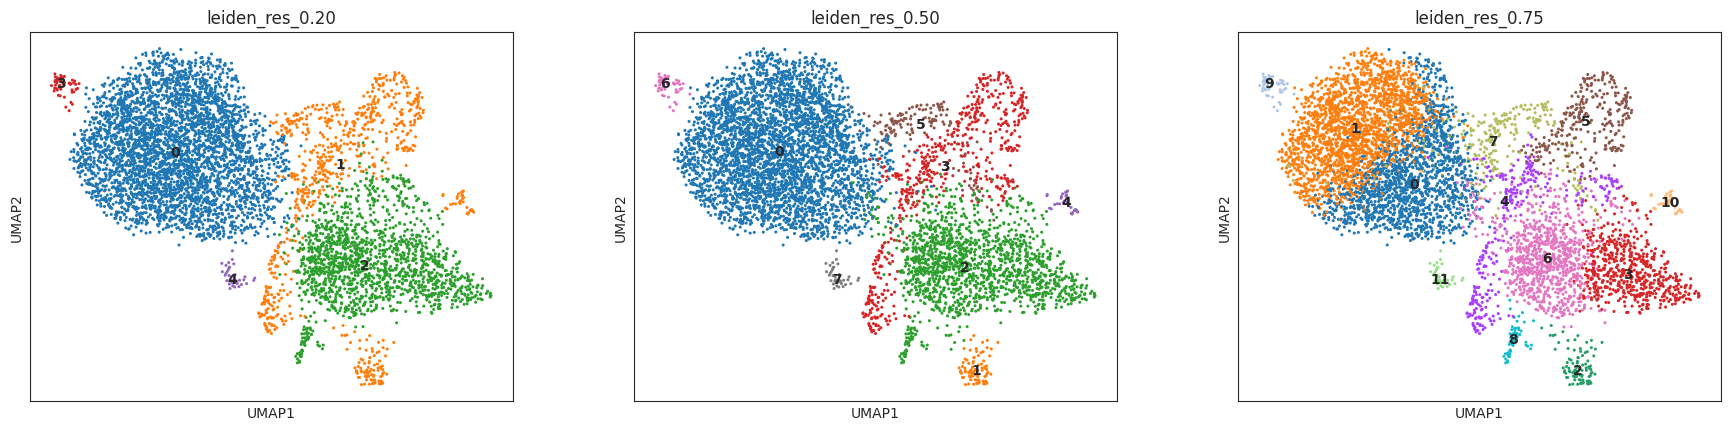

In [5]:
#STEP 3: GENERATE DIFFERENT RESOLUTIONS OF CLUSTERING

for res in [0.2, 0.5, 0.75]:
    sc.tl.leiden(adata_cd3_filtered, key_added=f"leiden_res_{res:4.2f}", resolution=res, flavor="igraph")

sc.pl.umap(
    adata_cd3_filtered,
    color=["leiden_res_0.20", "leiden_res_0.50", "leiden_res_0.75"],
    legend_loc="on data",
)

#### STEP 4: Loading the Color Palettes

Load the color palettes before we get into the graphs.

In [7]:
#STEP 4: LOAD COLOR PALETTES
infected_colors = {
    "5DPI": "#e88048",
    "Mock": "#582B36"
}

cluster_colors = ["#2E5283",
                  "#004100",
                  "#582B36",
                  "#E2552D",
                  "#009499",
                  "#E3BD33",
                  "#C67FAE",
                  "#A6BE47",
                  "#D7E8BC",
                  "#6D5698",
                  "#98DDDF",
                  "#A00239",
                  "#B623CC",
                  "#AC6C29",
                  "#333AFB",
                  "#10BCFE",
                  "#012731",
                  "#0D199A",
                  "#F53C9F",
                  "#BAA5FF",
                 "#FCD581"]
i_contrast_colors = ["#E2552D","#2E5283"]
ifitm_hex = ["#BEBDBD", "#DF3848"]
dp_hex = ["#FFFFFF","#0075B8"]
aggressive_hex = ["#FFFFFF","#000000"]

ifitm_cmap = mcolors.LinearSegmentedColormap.from_list("ifitm_cmap",ifitm_hex)
aggr_cmap = mcolors.LinearSegmentedColormap.from_list("aggr_cmap",aggressive_hex)
dp_cmap = mcolors.LinearSegmentedColormap.from_list("dp_cmap",dp_hex)

In [ ]:
print("\x1b[31m\"red\"\x1b[0m")

# **2. ANALYSIS METHODS**
Past this point, each analysis method is optional. These are a variety of different analyses that can be performed on the data to get results back. As new analyses are requested, this notebook will be updated.

## GENE ANALYSIS

## Getting all genes present in the data

This code block serves two purposes:
1. It can list every gene found in the entire dataset by looking at `adata_filtered.var_names`
2. It can find the overlap amongst a given list of genes, and can return which genes are and are not present.

In [ ]:
#Get all genes present in the dataset, and compare to those we want to know about
print("uncomment this when running interactively")
all_vars = list(adata_vg_filtered.var_names)
print(all_vars)

# all_gene = ["Nr1h4","Oas1g","Oas1b","Oas1c","Znrf1","Tnip2","Oas1h","Washc4","Syk","Socs5","Mcoln2","Traf3","Ripk2","Tnip3","Oas2","Il1rn","Sh2b3","Naip5","Naip6","Usp18","Naip7","Il7","Trim6","Pml","Ppard","Rorc","Mapk14","Nr5a2","Ddx17","Arv1","Ppargc1b","Zdhhc18","Mapkapk3","Cry1","Per2","Tcf7l2","Snord33","Snord32a","Pfkp","Crtc2","Rbm14","Trim30d","Ccr7","Lrrk2","Tmem106a","Bcl3","Crcp","Smad3","Arih2","Map3k14","Ifi27l2a","Atg16l1","Agbl5","Nlrp9b","2410002F23Rik","Akap8","Irs1","Macroh2a1","Mlxipl","Rptor","Epm2aip1","Tigar","1810024B03Rik","Pla2g5","Atat1","Il15ra","Jak3","Nsmaf","Ccl25","Cxcl12","Appl2","Sp100","Aqp4","Grin1","Pkd1","Ski","Tk1","Upb1","Kctd1","Tmem120b","Bend3","Trim72","Cd38","Sppl3","Shb","Vtcn1","Vps37b","Vav2","Fut2","St3gal3","St3gal4","St6galnac6","St3gal6","B4galt5","A4galt","St6galnac4","Mecr","Hacd1","Cert1","Arv1","Mgst2","Ahdc1","Pnpla1","Sgpp2","Htt","Acly","Acsl6"]
#all_gene = ["ABTB2","AC025171.1","ADAM9","ADAR","AIDA","AKR7A2","ANKFY1","AP3M2","APOBEC3G","APOL1","APOL2","APOL3","APOL4","APOL6","ARAP2","ARID3A","ARID5B","ARL4A","ATP10A","ATP6V0A4","ATP6V0B","AUTS2","AVPR2","B2M","BAG1","BAK1","BANK1","BATF2","BAX","BBC3","BBX","BCL2","BCLAF1","BPGM","BRCA1","BST2","BTG1","C1R","C1S","CALD1","CALR","CASP1","CASP3","CASP4","CASP7","CASP8","CCDC91","CCL2","CCL5","CCL7","CCNYL1","CCRL2","CD164","CD274","CD38","CD40","CD47","CD69","CD74","CD80","CD86","CDK1","CDKN1A","CDKN1B","CEACAM1","CEBPD","CFB","CFH","CGAS","CIITA","CLIC4","CMKLR1","CMPK2","CMTR1","CNP","COL16A1","CSF1","CSF2RB","CSRP3","CTR9","CX3CL1","CXCL10","CXCL11","CXCL9","CYB561D2","CYCS","CYP24A1","DCK","DDIT4","DDX1","DDX17","DDX21","DDX58","DDX60","DHX58","DNAJC2","DTX3L","E2F2","EHD4","EIF2AK2","EIF2B1","EIF3A","EIF4E3","ELF1","ELK4","EPRS1","EPS15","EPSTI1","ETS2","ETV7","FAM111A","FAM46A","FAS","FCGR1A","FGL2","FOSL1","FPR1","FUBP1","GBP1","GBP2","GBP3","GBP4","GBP5","GBP6","GBP7","GCH1","GIMAP7","GMFB","GMPR","GOLGA4","GOLM1","GPR18","GZMA","HADH","HADHB","HELZ2","HERC5","HERC6","HIF1A","HK2","HLA-A","HLA-B","HLA-C","HLA-DMA","HLA-DPA1","HLA-DQA1","HLA-DQB1","HLA-DRB1","HLA-DRB3","HLA-DRB4","HLA-DRB5","HLA-E","HLA-F","HLA-G","HPSE","HSD17B11","HSH2D","ICAM1","IDO1","IFI16","IFI27","IFI30","IFI35","IFI44","IFI44L","IFI6","IFIH1","IFIT1","IFIT2","IFIT3","IFIT5","IFITM1","IFITM2","IFITM3","IFNAR2","IL10RA","IL12RB2","IL15","IL15RA","IL18BP","IL1RN","IL23A","IL2RB","IL4R","IL6","IL7","IQGAP1","IRF1","IRF2","IRF4","IRF5","IRF7","IRF8","IRF9","ISG15","ISG20","ISOC1","ITGA2","ITGA4","ITGB7","JADE2","JAK2","KLK3","KLRK1","KPTN","LAMP3","LAP3","LAT","LATS2","LCP2","LGALS3BP","LGALS9","LILRB1","LINC01128","LIPA","LIPG","LPAR6","LRRC37A11P","LY6E","LYSMD2","MAP1B","MAP3K10","MAP3K14","MARCHF1","MAX","MB21D1","METTL7B","MIA3","MLKL","MMP25","MOV10","MS4A4A","MS4A6A","MT2A","MTHFD2","MVB12A","MVP","MX1","MX2","MXD4","MYD88","MYO1G","NAMPT","NAP1L1","NCOA3","NCOA7","NFKB1","NFKBIA","NLRC5","NMI","NOD1","NOS2","NR4A3","NT5C3A","NUB1","NUP93","NUP98","OAS1","OAS2","OAS3","OASL","OGFR","P2RY14","P2RY6","PANK2","PARP1","PARP11","PARP12","PARP14","PARP4","PARP9","PCGF5","PDE4B","PDXK","PELI1","PFKP","PHB","PHF11","PIAS4","PIK3AP1","PIM1","PLA1A","PLA2G4A","PLAAT4","PLAUR","PLOD2","PLSCR1","PMAIP1","PML","PNP","PNPT1","POLR2B","PPA1","PPM1K","PPP3CA","PPP5C","PRAF2","PRAME","PRKCQ","PROCR","PSMA2","PSMA3","PSMB10","PSMB2","PSMB8","PSMB9","PSME1","PSME2","PTGS2","PTPN1","PTPN11","PTPN2","PTPN6","PYHIN1","RABL3","RAC3","RAPGEF6","RBBP4","RBCK1","RBM43","RBMX","RFC2","RHOC","RIN2","RIPK1","RIPK2","RNASEL","RNF213","RNF31","RRP8","RSAD2","RTP4","SAMD9","SAMD9L","SAMHD1","SDC3","SDCBP","SECTM1","SELL","SELP","SEM1","SEPTIN4","SERPING1","SF3A1","SKP1","SLAMF7","SLC15A3","SLC25A28","SLC39A8","SLFN5","SMAD4","SMCHD1","SOCS1","SOCS3","SOD2","SP110","SPPL2A","SRI","SRP9","SRSF2","SSBP1","SSBP3","SSPN","ST3GAL5","ST8SIA4","STAT1","STAT2","STAT3","STAT4","SUN2","TAP1","TAPBP","TDRD7","TEAD1","TEAD4","TENT5A","TIPARP","TLK2","TMEM106A","TMEM140","TMEM176A","TNFAIP2","TNFAIP3","TNFAIP6","TNFSF10","TNIP3","TOR1B","TRAFD1","TRAPPC10","TREX1","TRIM14","TRIM21","TRIM22","TRIM25","TRIM26","TRIM5","TTYH2","TUBB","TXNIP","UBA7","UBD","UBE2D3","UBE2L6","UBE2Z","UPP1","USP18","USP25","VAMP5","VAMP8","VAT1","VCAM1","VCPIP1","VEGFC","WARS1","XAF1","XCL1","XRCC6","XRN1","ZBP1","ZC3HAV1","ZCCHC2","ZFP36L2","ZNFX1"]
# common_elements = [item for item in all_gene if item in all_vars]
#uncommon_elements = [uitem for uitem in all_gene if (uitem[0]+uitem[1:].lower()) not in all_vars]
# print(common_elements)
#print(uncommon_elements)


## Finding gene expression across clusters

This utilizes the masking property of adata objects to find the average value of specific gene expression across clusters

In [ ]:
#determining the average cell expression of a given gene and the bounds of cell expression per cluster

stop = max(int(item) for item in adata_filtered.obs['leiden_res_0.50'].cat.categories.tolist()) + 1

for i in range(0,stop):
    curr_cluster = adata_filtered[adata_filtered.obs['leiden_res_0.50']==str(i)][:,"Cd3e"].X
    cluster_mask = (curr_cluster.toarray().flatten() > 0)
    #print(curr_cluster)
    cd3_norm_mask = curr_cluster.toarray()
    all_cd3 = adata_filtered[adata_filtered.obs["leiden_res_0.50"]==str(i)].layers['counts'][cluster_mask,:]
    #print(all_cd3)
    print(f"Cluster {i}: min - {all_cd3.min()} | max - {all_cd3.max()} | average: {all_cd3.mean()}")
    print(f"Cluster {i} NORM: min - {cd3_norm_mask.min()} | max - {cd3_norm_mask.max()} | average: {cd3_norm_mask.mean()}")

# cd3 = adata_filtered[adata_filtered.obs['leiden_res_0.50']=="1"][:,"Cd3e"].X
# cluster_mask = (cd3.toarray().flatten() > 0)
# all_cd3 = adata_filtered[adata_filtered.obs["leiden_res_0.50"]=="1"].layers['counts'][cluster_mask,:]
# print(all_cd3)

## Dotplot of Most Differentially Expressed Genes

This code block plots a dotplot of the five most differentially expressed and ranked genes per cluster. This figure can be saved to an external image, or can be changed to show a different number of expressed genes across a different grouping.

In [ ]:
#Generate the top differentially expressed genes based on the specific groupby parameter
sc.tl.rank_genes_groups(adata_diet_filtered, groupby="leiden_res_0.50", method="wilcoxon")
sc.pl.rank_genes_groups_dotplot(
    adata_diet_filtered, groupby="leiden_res_0.50", standard_scale="var", n_genes=5
)

#if save is desired, can add save="leiden_dotplot.svg" to parameters

In [ ]:
#Ranking genes by infection then graphing by cluster cell type

#This code block is an example of ranking top different genes based on a different parameter, and then providing a 
#dotplot with a key to the different analysis. 
sc.tl.rank_genes_groups(adata_vg_filtered, groupby="leiden_res_0.75", method="wilcoxon")

sc.pl.rank_genes_groups_dotplot(
    adata_vg_filtered, groupby="leiden_res_0.75", standard_scale="var", n_genes=5
)

In [ ]:
#Generate the top differentially expressed genes based on the specific groupby parameter
sc.tl.rank_genes_groups(adata_cd3_filtered, groupby="leiden_res_0.50", method="wilcoxon")
sc.pl.rank_genes_groups_dotplot(
    adata_cd3_filtered, groupby="leiden_res_0.50", standard_scale="var", n_genes=10,save="help.png"
)

#if save is desired, can add save="leiden_dotplot.svg" to parameters

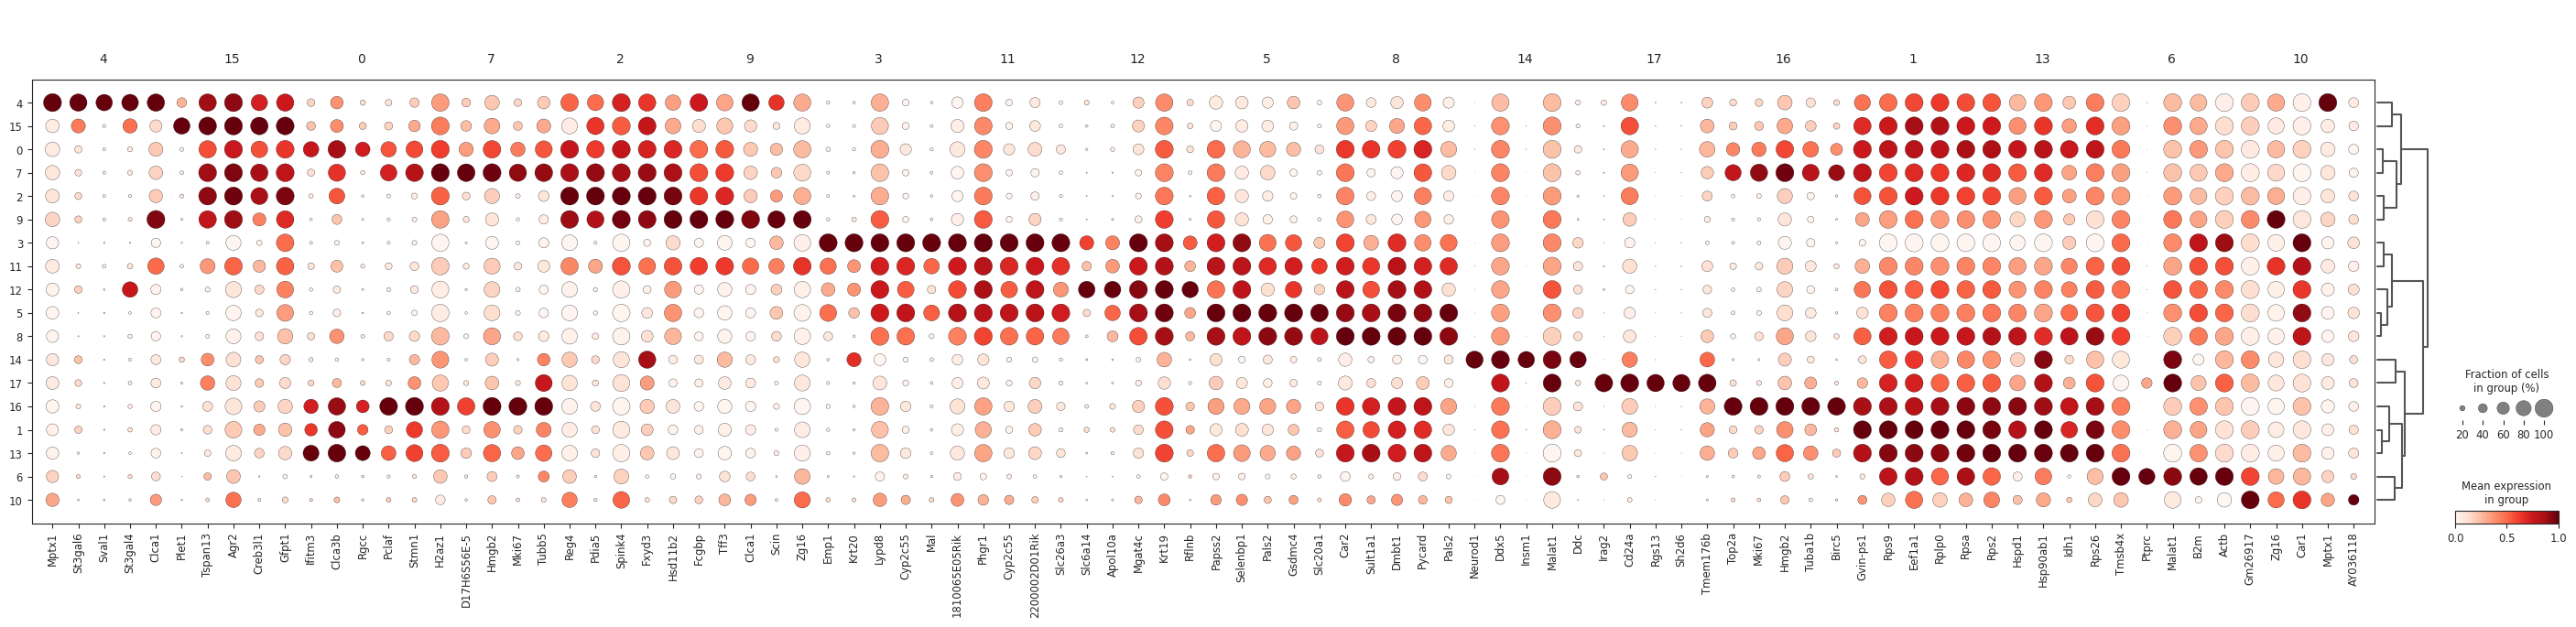

In [8]:
#Generate the top differentially expressed genes based on the specific groupby parameter
sc.tl.rank_genes_groups(adata_filtered, groupby="leiden_res_0.50", method="wilcoxon")
sc.pl.rank_genes_groups_dotplot(
    adata_filtered, groupby="leiden_res_0.50", standard_scale="var", n_genes=5
)

#if save is desired, can add save="leiden_dotplot.svg" to parameters

## MAKING A NEW CLUSTER SUBSET

In [34]:
#get subset of only cells with Cd3+ activity
#cd3 = adata_diet_filtered[:,'Spink4'].X

adata_cd3_diet_filteredf = adata_diet_filtered[
    (adata_diet_filtered[:,'Cd3e'].X.toarray() > 1) &
    (adata_diet_filtered[:,'Krt8'].X.toarray() == 0)
].copy()

adata_cd3_diet_filtered = adata_cd3_diet_filteredf[
    (adata_cd3_diet_filteredf[:,'Epcam'].X.toarray() > 0)
].copy()

print(adata_cd3_diet_filtered)

#adata_cd3_diet_filteredf = adata_cd3_diet_filtered[adata_cd3_diet_filtered.obs['leiden_res_0.20'].isin(['0','1','3'])].copy()

AnnData object with n_obs × n_vars = 810 × 13700
    obs: 'sample', 'treatment', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_genes', 'doublet_score', 'predicted_doublet', 'leiden', 'leiden_res_0.20', 'leiden_res_0.50', 'leiden_res_0.75'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'hvg', 'leiden', 'log1p', 'neighbors', 'pca', 'predicted_doublet_colors', 'scrublet', 'treatment_colors', 'umap', 'leiden_res_0.20', 'leiden_res_0.50', 'leiden_res_0.75', 'leiden_res_0.20_colors', 'leiden_res_0.50_colors', 'leiden_res_0.75_colors'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts'
    

In [35]:
sc.pp.neighbors(adata_cd3_diet_filtered)
sc.tl.umap(adata_cd3_diet_filtered)

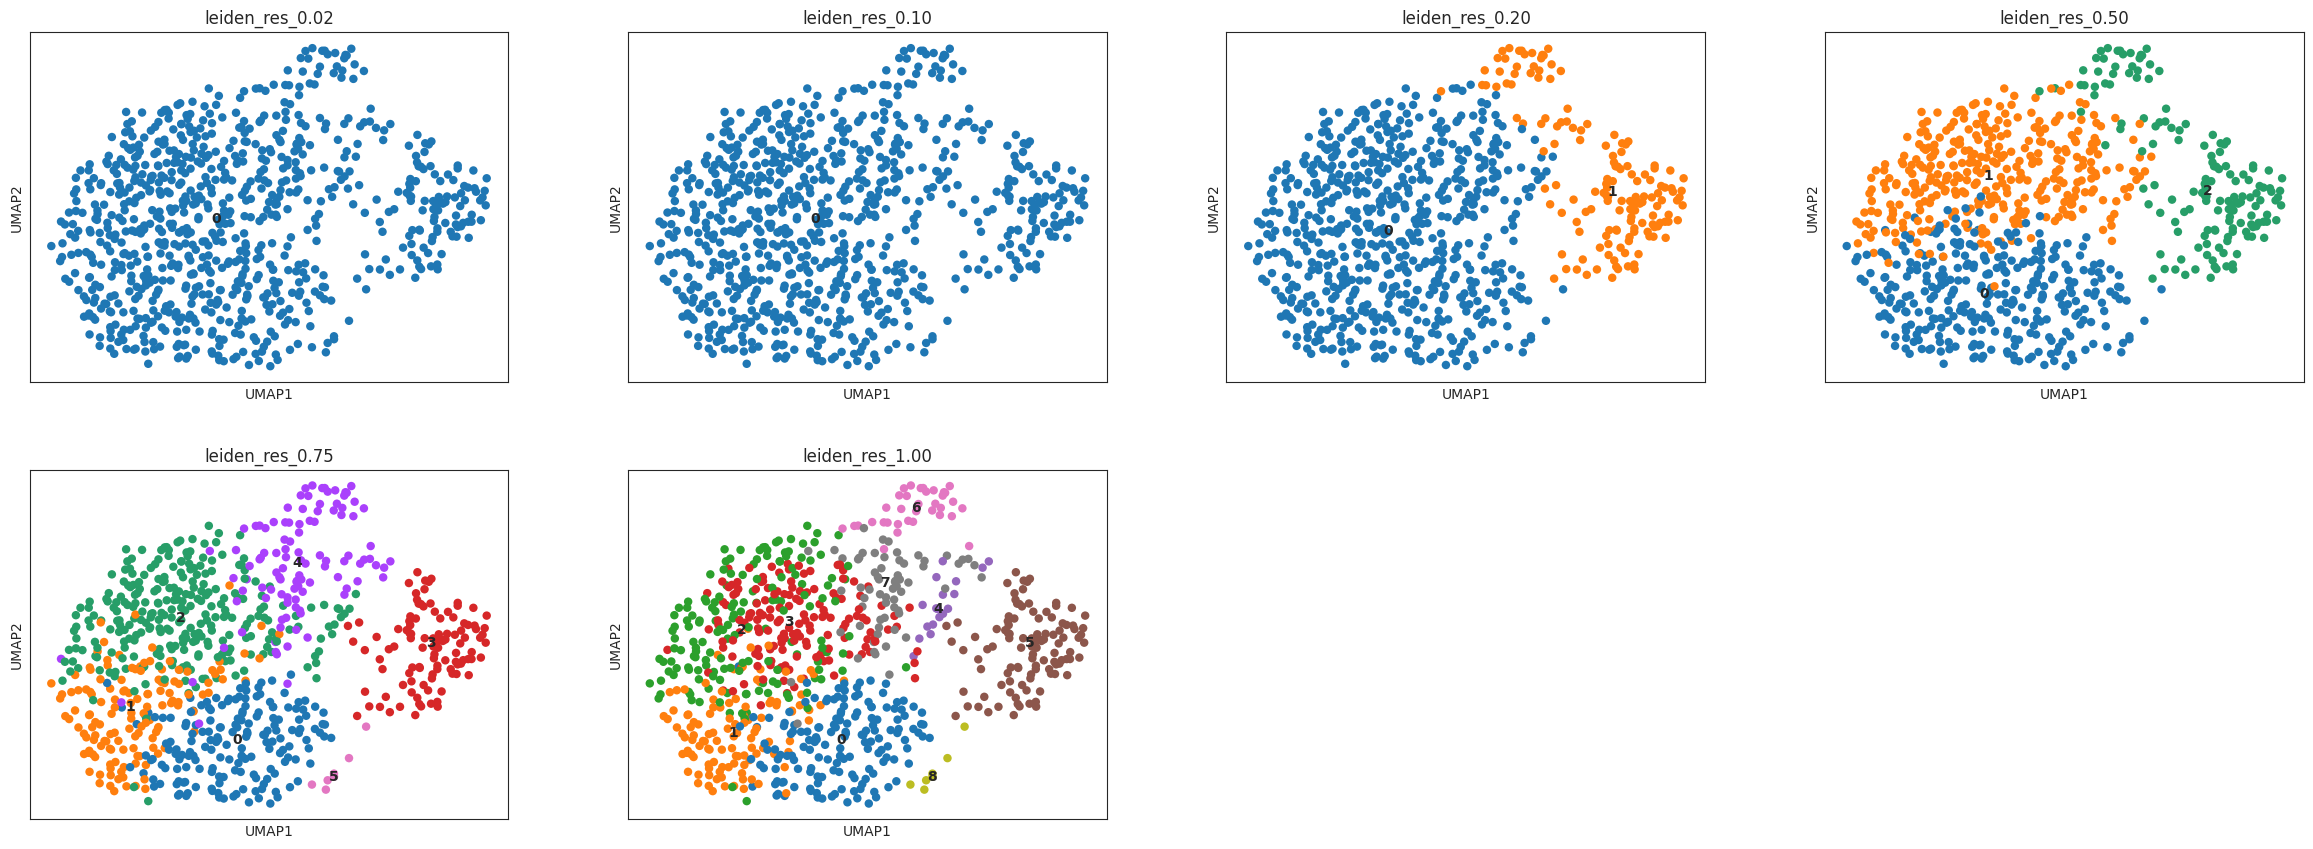

In [36]:
for res in [0.02, 0.1, 0.2, 0.5, 0.75, 1.0]:
    sc.tl.leiden(adata_cd3_diet_filtered, key_added=f"leiden_res_{res:4.2f}", resolution=res, flavor="igraph")

sc.pl.umap(
    adata_cd3_diet_filtered,
    color=["leiden_res_0.02", "leiden_res_0.10", "leiden_res_0.20", "leiden_res_0.50","leiden_res_0.75","leiden_res_1.00"],
    legend_loc="on data",
)

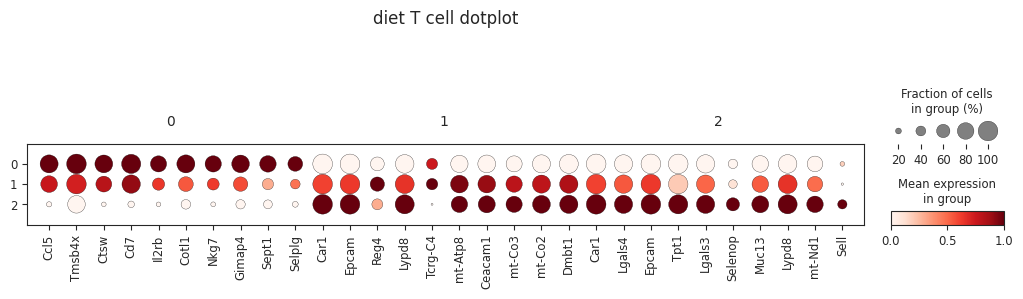

In [37]:
sc.tl.rank_genes_groups(adata_cd3_diet_filtered, groupby="leiden_res_0.50", method="wilcoxon")
sc.pl.rank_genes_groups_dotplot(
    adata_cd3_diet_filtered, groupby="leiden_res_0.50", standard_scale="var", n_genes=10,dendrogram=False, title="diet T cell dotplot"
)


In [42]:
#get subset of only cells with Cd3+ activity
#cd3 = adata_diet_filtered[:,'Spink4'].X

adata_cd3_vg_filtered = adata_cd3_filtered[
    (adata_cd3_filtered[:, 'Epcam'].X.toarray() == 0) &
    (adata_cd3_filtered[:, 'Cd3e'].X.toarray() > 1)
]

# if isinstance(cd3, (np.ndarray, list)):
#     #for dense arrays or lists
#     mask = muc.flatten() > 0
# else:
#     # For sparse matrices (e.g., csr_matrix)
#     mask = (cd3.toarray().flatten() > 0)

# adata_subset_view = adata_diet_filtered[~mask, :]

# adata_cd3_diet = adata_subset_view.copy()
print(adata_cd3_vg_filtered)

View of AnnData object with n_obs × n_vars = 1064 × 13592
    obs: 'sample', 'condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_genes', 'doublet_score', 'predicted_doublet', 'leiden'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'condition_colors', 'hvg', 'leiden', 'log1p', 'neighbors', 'pca', 'predicted_doublet_colors', 'scrublet', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'connectivities', 'distances'


In [43]:
sc.pp.neighbors(adata_cd3_vg_filtered)
sc.tl.umap(adata_cd3_vg_filtered)

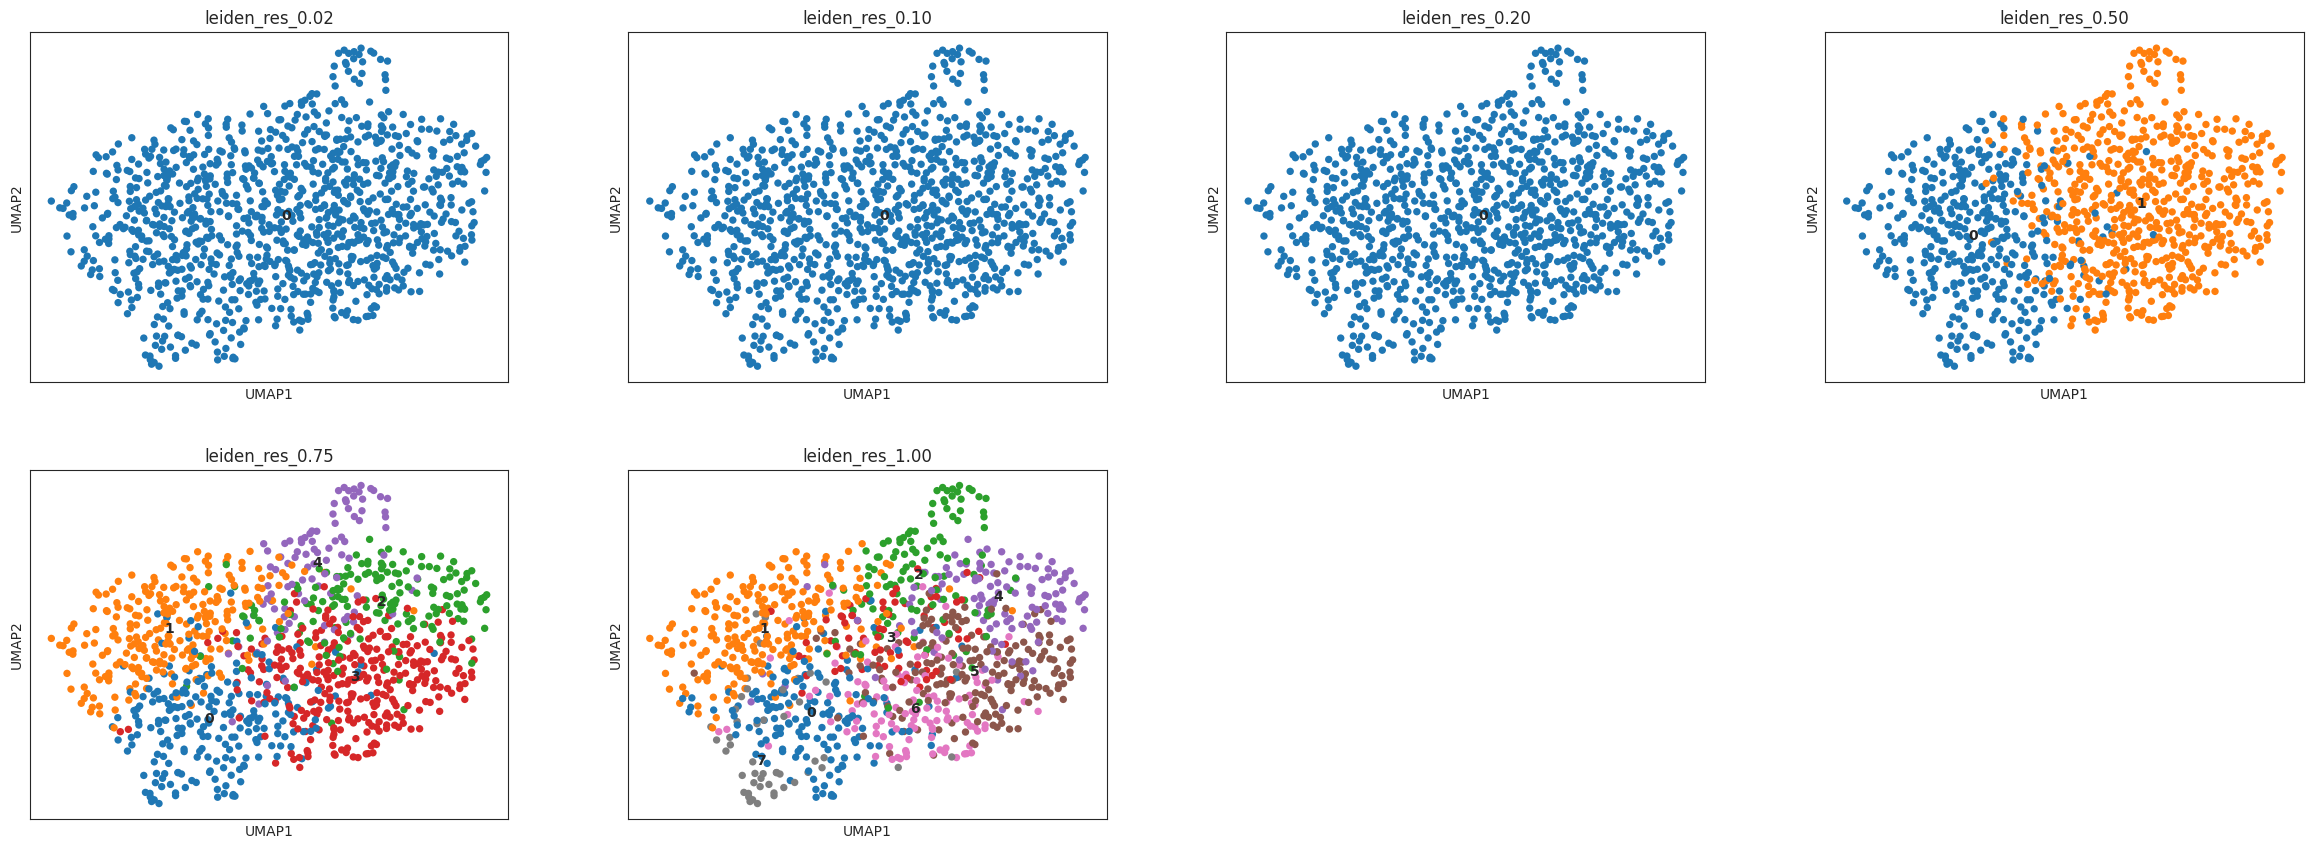

In [44]:
for res in [0.02, 0.1, 0.2, 0.5, 0.75, 1.0]:
    sc.tl.leiden(adata_cd3_vg_filtered, key_added=f"leiden_res_{res:4.2f}", resolution=res, flavor="igraph")

sc.pl.umap(
    adata_cd3_vg_filtered,
    color=["leiden_res_0.02", "leiden_res_0.10", "leiden_res_0.20", "leiden_res_0.50","leiden_res_0.75","leiden_res_1.00"],
    legend_loc="on data",
)

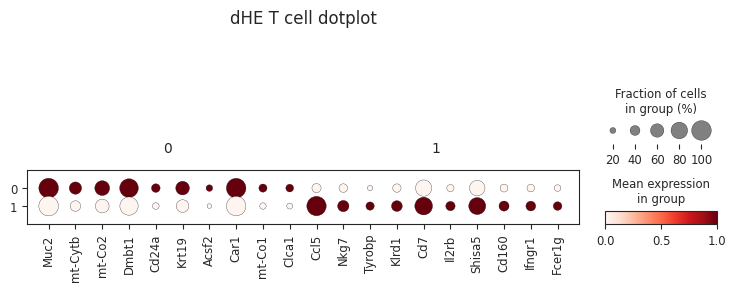

In [45]:
sc.tl.rank_genes_groups(adata_cd3_vg_filtered, groupby="leiden_res_0.50", method="wilcoxon")
sc.pl.rank_genes_groups_dotplot(
    adata_cd3_vg_filtered, groupby="leiden_res_0.50", standard_scale="var", n_genes=10,dendrogram=False, title="dHE T cell dotplot"
)


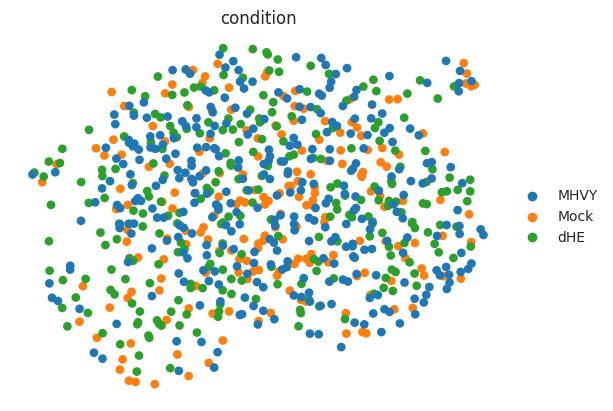

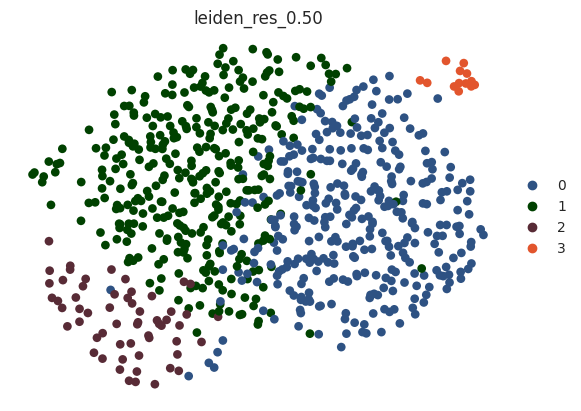

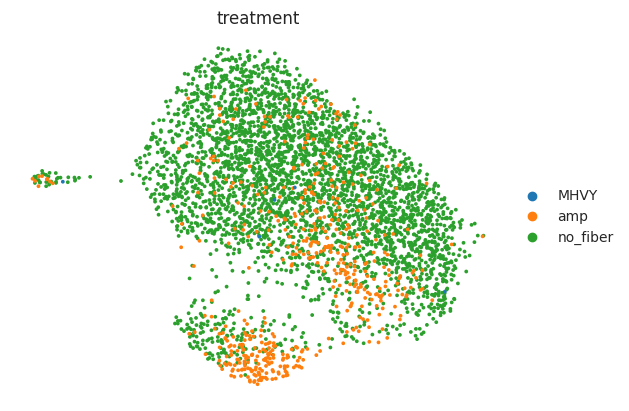

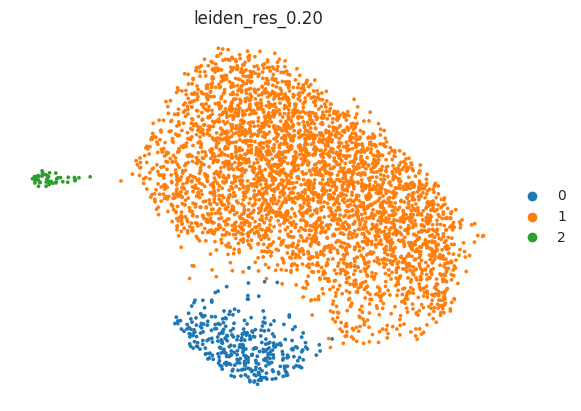

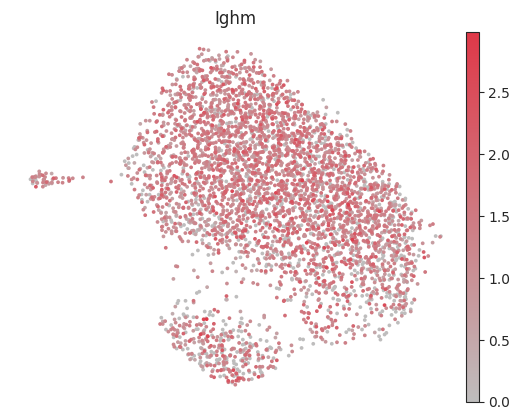

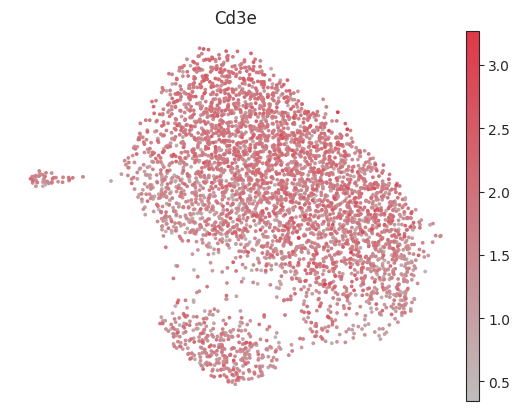

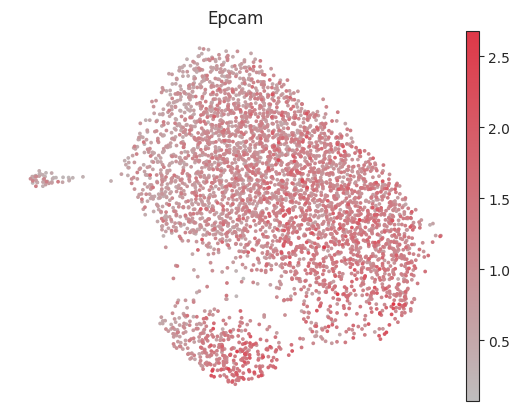

In [79]:
#sc.pl.umap(adata_cd3_vg_filtered, color="Gzmh", cmap=ifitm_cmap,frameon=False)
sc.pl.umap(adata_cd3_vg_filtered, color="condition", cmap=ifitm_cmap,frameon=False)
sc.pl.umap(adata_cd3_vg_filtered, color="leiden_res_0.50", palette=cluster_colors,frameon=False)

sc.pl.umap(adata_cd3_diet_filtered, color="treatment", cmap=ifitm_cmap,frameon=False)
sc.pl.umap(adata_cd3_diet_filtered, color="leiden_res_0.20", cmap=ifitm_cmap,frameon=False)
sc.pl.umap(adata_cd3_diet_filtered, color="Ighm", cmap=ifitm_cmap,frameon=False)
sc.pl.umap(adata_cd3_diet_filtered, color="Cd3e", cmap=ifitm_cmap,frameon=False)
sc.pl.umap(adata_cd3_diet_filtered, color="Epcam", cmap=ifitm_cmap,frameon=False)

### ALL IL GRAPHING ###

# for var_name in all_vars:
#     il_match = re.search(f"Gzm",var_name)
#     if il_match is not None:
#         sc.pl.umap(adata_filtered, color=var_name,frameon=False,cmap=ifitm_cmap)



In [46]:
sc.tl.rank_genes_groups(adata_cd3_diet_filtered, groupby="treatment", method='wilcoxon',reference="MHVY",key_added="diet_IEL")
sc.tl.rank_genes_groups(adata_cd3_vg_filtered, groupby="condition", method='wilcoxon',reference="MHVY",key_added="vg_IEL")
df_diet_amp = sc.get.rank_genes_groups_df(adata_cd3_diet_filtered, group="amp",key="diet_IEL")
df_diet_nf = sc.get.rank_genes_groups_df(adata_cd3_diet_filtered, group="no_fiber",key="diet_IEL")
df_vg_dHE = sc.get.rank_genes_groups_df(adata_cd3_vg_filtered, group="dHE",key="vg_IEL")
df_vg_mock = sc.get.rank_genes_groups_df(adata_cd3_vg_filtered, group="Mock",key="vg_IEL")

In [47]:
df_diet_amp.to_csv("20260417_amp_IEL_DEG.csv",index=False)
df_diet_nf.to_csv("20260417_nf_IEL_DEG.csv",index=False)
df_vg_dHE.to_csv("20260417_dHE_IEL_DEG.csv",index=False)
df_vg_mock.to_csv("20260417_vg_mock_IEL_DEG.csv",index=False)

# PLOTTING

This cell block contains all of the code to plot different groups or characteristics.

#### UMAP Plotting

The main format for UMAP plotting is: 

`sc.pl.umap(adata_filtered, color=<gene>, size=<int>, mask_obs=(adata_filtered.obs.<category>==<group>), cmap=<colormap> OR palette=<palette>, frameon=False, save=<output filename>)`

Parameters: 

- adata_filtered: the AnnData object with all of the data. **required**
- color: the value to plot within the population (typically a gene, i.e. Ifit1, Cd3e, Il11, etc...) **required**
- size: size of the dot to plot on the map
- mask_obs: masks a part of the data such that their values are NOT mapped according to the `color` parameter (they instead show up as a gray "NA" population)
- cmap / palette: determines what colors are used to plot the values. cmap is for a continuous gradient (like expression values) while palette is for discrete categorical values (like infection type)
- frameon: determines if there is a frame around the plot
- save: saves the outputted figure. will always give a warning and the saved filepath (usually `./figures/umap/<output filename>`)

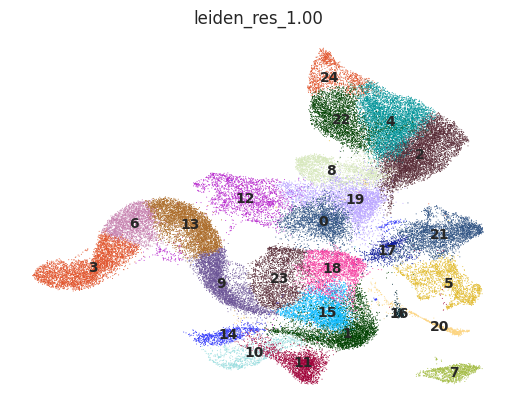

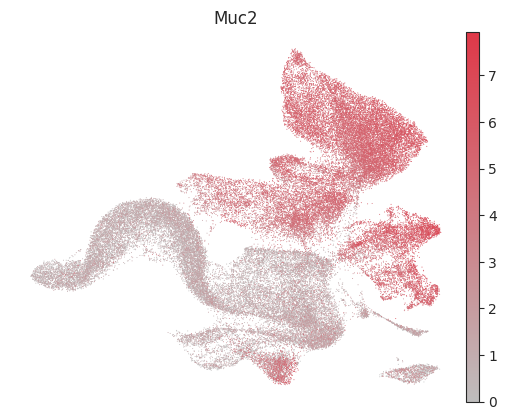

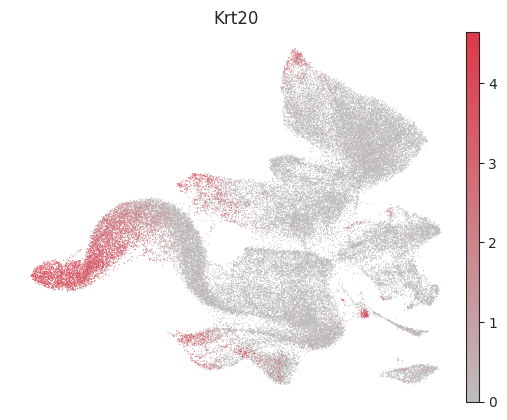

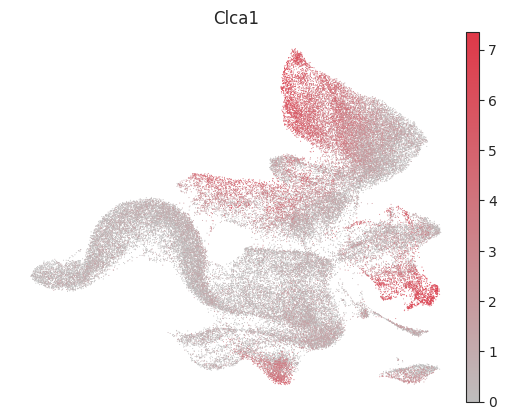

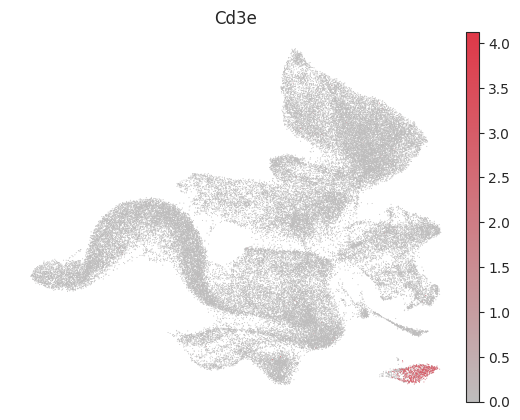

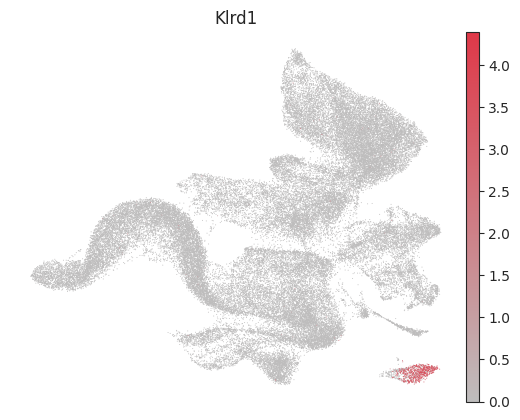

In [12]:
#BASIC PLOTS
#sc.pl.umap(adata_vg_filtered, color="cluster_cell_type",frameon=False,title="viral_genetics",palette=cluster_colors)
sc.pl.umap(adata_filtered, color="leiden_res_1.00",frameon=False,palette=cluster_colors,legend_loc="on data")
#sc.pl.umap(adata_cd3_filtered, color="condition",frameon=False,title="condition",palette=cluster_colors)
#sc.pl.umap(adata_diet_filtered, color="leiden_res_0.50",legend_loc="on data",frameon=False,title="diet")

# sc.pl.umap(adata_cd3_filtered, color="condition",mask_obs=(adata_cd3_filtered.obs["condition"]=="Mock"),frameon=False,title="Mock",save="/presentation/mock_cd3_only.png")
# sc.pl.umap(adata_cd3_filtered, color="condition",mask_obs=(adata_cd3_filtered.obs["condition"]=="MHVY"),frameon=False,title="mhvy",save="/presentation/mhvy_cd3_only.png")
# sc.pl.umap(adata_cd3_filtered, color="condition",mask_obs=(adata_cd3_filtered.obs["condition"]=="dHE"),frameon=False,title="dHE",save="/presentation/dhe_cd3_only.png")

# sc.pl.umap(adata_vg_filtered, color="condition",mask_obs=(adata_vg_filtered.obs["condition"]=="Mock"),frameon=False,title="Mock",save="/presentation/mock_vg_only.png")
# sc.pl.umap(adata_vg_filtered, color="condition",mask_obs=(adata_vg_filtered.obs["condition"]=="MHVY"),frameon=False,title="mhvy",save="/presentation/mhvy_vg_only.png")
# sc.pl.umap(adata_vg_filtered, color="condition",mask_obs=(adata_vg_filtered.obs["condition"]=="dHE"),frameon=False,title="dHE",save="/presentation/dhe_vg_only.png")

# sc.pl.umap(adata_diet_filtered, color="treatment",mask_obs=(adata_diet_filtered.obs["treatment"]=="no_fiber"),frameon=False,title="no fiber",save="/presentation/no_fiber_only.png")
# sc.pl.umap(adata_diet_filtered, color="treatment",mask_obs=(adata_diet_filtered.obs["treatment"]=="MHVY"),frameon=False,title="mhvy",save="/presentation/mhvy_diet_only.png")
# sc.pl.umap(adata_diet_filtered, color="treatment",mask_obs=(adata_diet_filtered.obs["treatment"]=="amp"),frameon=False,title="amp",save="/presentation/amp_only.png")

# sc.pl.umap(adata_filtered, color="leiden",frameon=False,mask_obs=(adata_filtered.obs["treatment"]=="amp"),title="amp")
# sc.pl.umap(adata_filtered, color="leiden",frameon=False,mask_obs=(adata_filtered.obs["treatment"]=="no_fiber"),title="no fiber")

#sc.pl.umap(adata_diet_filtered, color="Clca1",frameon=False,cmap=ifitm_cmap,save="viral_genetics_clca1.png")
sc.pl.umap(adata_filtered, color="Muc2",frameon=False,cmap=ifitm_cmap)
sc.pl.umap(adata_filtered, color="Krt20",frameon=False,cmap=ifitm_cmap)
sc.pl.umap(adata_filtered, color="Clca1",frameon=False,cmap=ifitm_cmap)
#sc.pl.umap(adata_vg_filtered, color="Tnfsf11",frameon=False,cmap=ifitm_cmap)
#sc.pl.umap(adata_vg_filtered, color="Thbs1",frameon=False,cmap=ifitm_cmap,mask_obs=(adata_vg_filtered.obs["condition"]=="dHE"),save="/presentation/thbs1_dHE.png")
#sc.pl.umap(adata_vg_filtered, color="Thbs1",frameon=False,cmap=ifitm_cmap,mask_obs=(adata_vg_filtered.obs["condition"]=="Mock"),save="/presentation/thbs1_mock.png")
#sc.pl.umap(adata_vg_filtered, color="Thbs1",frameon=False,cmap=ifitm_cmap,mask_obs=(adata_vg_filtered.obs["condition"]=="MHVY"),save="/presentation/thbs1_mhvy.png")
# # sc.pl.umap(adata_vg_filtered, color="condition",frameon=False,cmap=ifitm_cmap,)
# #sc.pl.umap(adata_cd3_filtered, color="Tnfsf11",frameon=False,cmap=ifitm_cmap)

#Ighg3 = IgG3, stimulated by IgA B cells

# sc.pl.umap(adata_filtered, color="Ets2",frameon=False,cmap=ifitm_cmap,mask_obs=(adata_vg_filtered.obs["condition"]=="dHE"))
# sc.pl.umap(adata_filtered, color="Ets2",frameon=False,cmap=ifitm_cmap,mask_obs=(adata_vg_filtered.obs["condition"]=="Mock"))
# sc.pl.umap(adata_filtered, color="Ets2",frameon=False,cmap=ifitm_cmap,mask_obs=(adata_vg_filtered.obs["condition"]=="MHVY"))
#sc.pl.umap(adata_filtered, color="Igha",frameon=False,cmap=ifitm_cmap)
sc.pl.umap(adata_filtered, color="Cd3e",frameon=False,cmap=ifitm_cmap)
#sc.pl.umap(adata_vg_filtered, color="Itgb6",frameon=False,cmap=ifitm_cmap,save="/presentation/itgb6.png")
sc.pl.umap(adata_filtered, color="Klrd1",frameon=False,cmap=ifitm_cmap)
#sc.pl.umap(adata_diet_filtered, color="Muc2",frameon=False,cmap=ifitm_cmap,mask_obs=(adata_diet_filtered.obs["treatment"]=="MHVY"))
#sc.pl.umap(adata_cd3_filtered, color="leiden_res_0.50",frameon=False,cmap=ifitm_cmap)
# sc.pl.umap(adata_cd3_filtered, color="Cd4",frameon=False,cmap=ifitm_cmap,save="/presentation/cd4.png")
# sc.pl.umap(adata_cd3_filtered, color="Cd8a",frameon=False,cmap=ifitm_cmap,save="/presentation/cd8a.png")
#sc.pl.umap(adata_cd3_filtered, color="Gzmb",frameon=False,cmap=ifitm_cmap)
# # sc.pl.umap(adata_filtered, color="B3galt5",frameon=False,cmap=ifitm_cmap,mask_obs=(adata_filtered.obs["treatment"]=="MHVY"))
# # sc.pl.umap(adata_filtered, color="B3galt5",frameon=False,cmap=ifitm_cmap,mask_obs=(adata_filtered.obs["treatment"]=="amp"))
# # sc.pl.umap(adata_filtered, color="B3galt5",frameon=False,cmap=ifitm_cmap,mask_obs=(adata_filtered.obs["treatment"]=="no_fiber"))
# # sc.pl.umap(adata_filtered, color="Tgfb1",frameon=False,cmap=ifitm_cmap)
# # sc.pl.umap(adata_filtered, color="Cd3d",frameon=False,cmap=ifitm_cmap)
# # sc.pl.umap(adata_filtered, color="Ifng",frameon=False,cmap=ifitm_cmap)

# sc.pl.umap(adata_filtered, color="Cd3e",frameon=False,cmap=ifitm_cmap,mask_obs=(adata_filtered.obs["treatment"]=="MHVY"),title="MHVY")
# sc.pl.umap(adata_filtered, color="Cd3e",frameon=False,cmap=ifitm_cmap,mask_obs=(adata_filtered.obs["treatment"]=="amp"),title="amp")
# sc.pl.umap(adata_filtered, color="Cd3e",frameon=False,cmap=ifitm_cmap,mask_obs=(adata_filtered.obs["treatment"]=="no_fiber"),title="no fiber")
# sc.pl.umap(adata_filtered, color="group",groups="5DPI",frameon=False,palette=i_contrast_colors)
# #sc.pl.umap(adata_filtered, color="Scin",frameon=False,cmap=ifitm_cmap,save="scin.svg")
# sc.pl.umap(adata_filtered, color=adata_filtered.var['mt'],frameon=False,cmap=ifitm_cmap,mask_obs=(adata_filtered.obs.group=="Mock"))
# sc.pl.umap(adata_filtered, color="Il11",frameon=False,cmap=ifitm_cmap,mask_obs=(adata_filtered.obs.group=="5DPI"))
#sc.pl.umap(adata_filtered, color="group", frameon=False,palette=i_contrast_colors,title="cell sample types",save="sampleumap.svg")
# sc.pl.umap(adata_filtered, color="cluster_cell_type", frameon=False, title="cell clustering",save="i_contrast.jpg")
# sc.pl.umap(my_subset, color=["cluster_cell_type"],palette=cluster_colors,frameon=False)
# sc.pl.umap(my_subset, color="Ramp1",frameon=False,cmap=ifitm_cmap,mask_obs=(my_subset.obs.group=="Mock"))
# sc.pl.umap(my_subset, color="Ramp1",frameon=False,cmap=ifitm_cmap,mask_obs=(my_subset.obs.group=="5DPI"))
# sc.pl.umap(my_subset, color="Clca1",frameon=False,cmap=ifitm_cmap,mask_obs=(my_subset.obs.group=="Mock"))


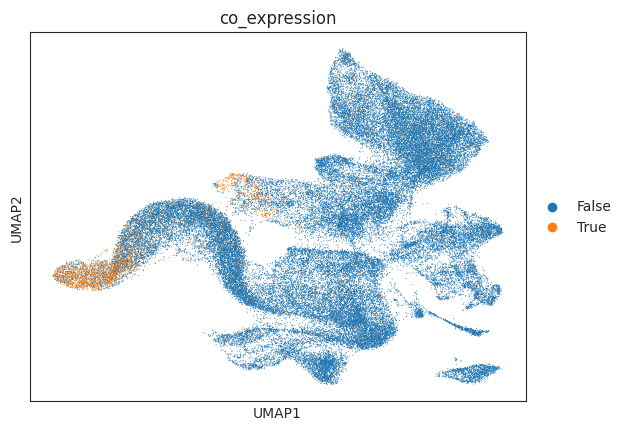

In [17]:
dfa = adata_filtered.to_df()
# Create boolean for co-expression (e.g., Gene1 > 0 AND Gene2 > 0)
co_expr = (dfa['Aqp8'] > 0.5) & (dfa['Muc2'] > 0.5)
# Add back to metadata
adata_filtered.obs['co_expression'] = co_expr.astype(str)
# Plot cells with both genes
sc.pl.umap(adata_filtered, color='co_expression')

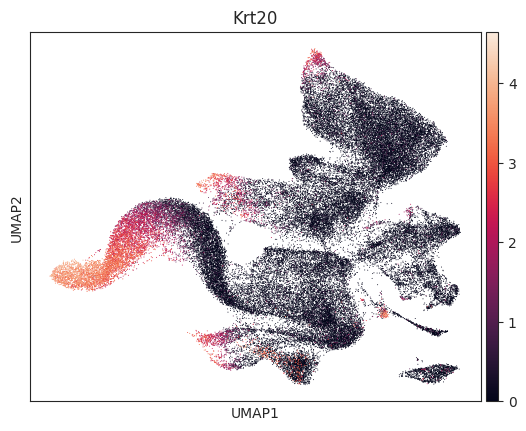

In [14]:
sc.pl.umap(adata_filtered,color="Krt20")

In [16]:
del dfa

In [19]:
gene_name = 'Muc2'
cluster_id = 'True'
cluster_col = 'co_expression'

# Get data for the gene and cluster
df = sc.get.obs_df(adata_vg_filtered, keys=[cluster_col, gene_name])

# Calculate average
avg_expr = df.groupby(cluster_col)[gene_name].mean()[cluster_id]
print(f"Average expression of {gene_name} in cluster {cluster_id}: {avg_expr}")

Average expression of Muc2 in cluster True: 3.8003199100494385


## PLOTTING A LIST OF GENES

If you have a gene list, you can put the list here and this code will iterate through the entire list and save to their respective gene title

In [ ]:
#all_il = ['Il17a','Il17f','Il24','Il20','Il19','Il10','Il1f8','Il1f9','Il1f6','Il1f5','Il1f10','Il1a','Il1b','Il7','Il2','Il21','Il12a','Il6','Il31','Il11','Il16','Il27','Il15','Il34','Il17c','Il18','Il23a','Il5','Il4','Il13','Il3','Il12b','Il9','Il25','Il17d','Il17b','Il33']
# all_gene = ['Nr1h4', 'Oas1g', 'Oas1c', 'Znrf1', 'Tnip2', 'Oas1h', 'Washc4', 'Syk', 'Socs5', 'Mcoln2', 'Traf3', 'Ripk2', 'Tnip3', 'Oas2', 'Il1rn', 'Sh2b3', 'Naip5', 'Naip6', 'Usp18', 'Il7', 'Trim6', 'Pml', 'Ppard', 'Rorc', 'Mapk14', 'Nr5a2', 'Ddx17', 'Arv1', 'Ppargc1b', 'Zdhhc18', 'Mapkapk3', 'Cry1', 'Per2', 'Tcf7l2', 'Pfkp', 'Crtc2', 'Rbm14', 'Trim30d', 'Ccr7', 'Lrrk2', 'Tmem106a', 'Bcl3', 'Crcp', 'Smad3', 'Arih2', 'Map3k14', 'Ifi27l2a', 'Atg16l1', 'Agbl5', 'Nlrp9b', 'Akap8', 'Irs1', 'Mlxipl', 'Rptor', 'Epm2aip1', 'Tigar', 'Pla2g5', 'Atat1', 'Il15ra', 'Jak3', 'Nsmaf', 'Ccl25', 'Cxcl12', 'Appl2', 'Sp100', 'Aqp4', 'Grin1', 'Pkd1', 'Ski', 'Tk1', 'Upb1', 'Kctd1', 'Tmem120b', 'Bend3', 'Cd38', 'Sppl3', 'Shb', 'Vtcn1', 'Vps37b', 'Vav2', 'Fut2', 'St3gal3', 'St3gal4', 'St6galnac6', 'St3gal6', 'B4galt5', 'A4galt', 'St6galnac4', 'Mecr', 'Hacd1', 'Arv1', 'Mgst2', 'Ahdc1', 'Pnpla1', 'Sgpp2', 'Htt', 'Acly', 'Acsl6']
# all_gene = ["Acacb","Acad11","Acat1","Etfb","Etfa","Acadl","Acadm","Acadvl","Acaa1a","Acads","Acox1","Adipoq","Akt1","Akt2","Abcd1","Auh","Cnr1","Cpt1a","Cpt1b","Cpt2","Crat","Eci1","Fabp1","Hadh","Hsd17b10","Hsd17b4","Irs1","Lep","Pex7","Ppara","Ppard","Abcd3","Abcd4","Pex2","Pex5","Scp2","Slc25a17","Aldh1l2","Twist1","Obp2a","Sesn2","Hadhb","Acaa1b","Eci2","Slc27a2","Abcd2","Gcdh","Abcb11","Etfbkmt","Acsbg2","Acad12","Irs2","Acsl5","Ech1","Echdc2","Acaa2","Echdc1","Ivd","Mlycd","Mtor","Etfdh","Acadsb","Lonp2","Acad8","Plin5","Decr1","Mtln","Eci3","Bdh2","Tysnd1","Acad10","Crot","Acoxl","Ehhadh","Mfsd2a","Acox3","Acox2","Echs1","Hadha"]
all_gene = ["ABTB2","AC025171.1","ADAM9","ADAR","AIDA","AKR7A2","ANKFY1","AP3M2","APOBEC3G","APOL1","APOL2","APOL3","APOL4","APOL6","ARAP2","ARID3A","ARID5B","ARL4A","ATP10A","ATP6V0A4","ATP6V0B","AUTS2","AVPR2","B2M","BAG1","BAK1","BANK1","BATF2","BAX","BBC3","BBX","BCL2","BCLAF1","BPGM","BRCA1","BST2","BTG1","C1R","C1S","CALD1","CALR","CASP1","CASP3","CASP4","CASP7","CASP8","CCDC91","CCL2","CCL5","CCL7","CCNYL1","CCRL2","CD164","CD274","CD38","CD40","CD47","CD69","CD74","CD80","CD86","CDK1","CDKN1A","CDKN1B","CEACAM1","CEBPD","CFB","CFH","CGAS","CIITA","CLIC4","CMKLR1","CMPK2","CMTR1","CNP","COL16A1","CSF1","CSF2RB","CSRP3","CTR9","CX3CL1","CXCL10","CXCL11","CXCL9","CYB561D2","CYCS","CYP24A1","DCK","DDIT4","DDX1","DDX17","DDX21","DDX58","DDX60","DHX58","DNAJC2","DTX3L","E2F2","EHD4","EIF2AK2","EIF2B1","EIF3A","EIF4E3","ELF1","ELK4","EPRS1","EPS15","EPSTI1","ETS2","ETV7","FAM111A","FAM46A","FAS","FCGR1A","FGL2","FOSL1","FPR1","FUBP1","GBP1","GBP2","GBP3","GBP4","GBP5","GBP6","GBP7","GCH1","GIMAP7","GMFB","GMPR","GOLGA4","GOLM1","GPR18","GZMA","HADH","HADHB","HELZ2","HERC5","HERC6","HIF1A","HK2","HLA-A","HLA-B","HLA-C","HLA-DMA","HLA-DPA1","HLA-DQA1","HLA-DQB1","HLA-DRB1","HLA-DRB3","HLA-DRB4","HLA-DRB5","HLA-E","HLA-F","HLA-G","HPSE","HSD17B11","HSH2D","ICAM1","IDO1","IFI16","IFI27","IFI30","IFI35","IFI44","IFI44L","IFI6","IFIH1","IFIT1","IFIT2","IFIT3","IFIT5","IFITM1","IFITM2","IFITM3","IFNAR2","IL10RA","IL12RB2","IL15","IL15RA","IL18BP","IL1RN","IL23A","IL2RB","IL4R","IL6","IL7","IQGAP1","IRF1","IRF2","IRF4","IRF5","IRF7","IRF8","IRF9","ISG15","ISG20","ISOC1","ITGA2","ITGA4","ITGB7","JADE2","JAK2","KLK3","KLRK1","KPTN","LAMP3","LAP3","LAT","LATS2","LCP2","LGALS3BP","LGALS9","LILRB1","LINC01128","LIPA","LIPG","LPAR6","LRRC37A11P","LY6E","LYSMD2","MAP1B","MAP3K10","MAP3K14","MARCHF1","MAX","MB21D1","METTL7B","MIA3","MLKL","MMP25","MOV10","MS4A4A","MS4A6A","MT2A","MTHFD2","MVB12A","MVP","MX1","MX2","MXD4","MYD88","MYO1G","NAMPT","NAP1L1","NCOA3","NCOA7","NFKB1","NFKBIA","NLRC5","NMI","NOD1","NOS2","NR4A3","NT5C3A","NUB1","NUP93","NUP98","OAS1","OAS2","OAS3","OASL","OGFR","P2RY14","P2RY6","PANK2","PARP1","PARP11","PARP12","PARP14","PARP4","PARP9","PCGF5","PDE4B","PDXK","PELI1","PFKP","PHB","PHF11","PIAS4","PIK3AP1","PIM1","PLA1A","PLA2G4A","PLAAT4","PLAUR","PLOD2","PLSCR1","PMAIP1","PML","PNP","PNPT1","POLR2B","PPA1","PPM1K","PPP3CA","PPP5C","PRAF2","PRAME","PRKCQ","PROCR","PSMA2","PSMA3","PSMB10","PSMB2","PSMB8","PSMB9","PSME1","PSME2","PTGS2","PTPN1","PTPN11","PTPN2","PTPN6","PYHIN1","RABL3","RAC3","RAPGEF6","RBBP4","RBCK1","RBM43","RBMX","RFC2","RHOC","RIN2","RIPK1","RIPK2","RNASEL","RNF213","RNF31","RRP8","RSAD2","RTP4","SAMD9","SAMD9L","SAMHD1","SDC3","SDCBP","SECTM1","SELL","SELP","SEM1","SEPTIN4","SERPING1","SF3A1","SKP1","SLAMF7","SLC15A3","SLC25A28","SLC39A8","SLFN5","SMAD4","SMCHD1","SOCS1","SOCS3","SOD2","SP110","SPPL2A","SRI","SRP9","SRSF2","SSBP1","SSBP3","SSPN","ST3GAL5","ST8SIA4","STAT1","STAT2","STAT3","STAT4","SUN2","TAP1","TAPBP","TDRD7","TEAD1","TEAD4","TENT5A","TIPARP","TLK2","TMEM106A","TMEM140","TMEM176A","TNFAIP2","TNFAIP3","TNFAIP6","TNFSF10","TNIP3","TOR1B","TRAFD1","TRAPPC10","TREX1","TRIM14","TRIM21","TRIM22","TRIM25","TRIM26","TRIM5","TTYH2","TUBB","TXNIP","UBA7","UBD","UBE2D3","UBE2L6","UBE2Z","UPP1","USP18","USP25","VAMP5","VAMP8","VAT1","VCAM1","VCPIP1","VEGFC","WARS1","XAF1","XCL1","XRCC6","XRN1","ZBP1","ZC3HAV1","ZCCHC2","ZFP36L2","ZNFX1"]
all_vars = list(my_var.upper() for my_var in adata_filtered.var_names)

for gene in all_gene:
    if gene in all_vars:
        gene_to_plot = gene[0] + gene[1:].lower()
        sc.pl.umap(adata_filtered, color=gene_to_plot,frameon=False,cmap=ifitm_cmap,save=f"/isgs/{gene_to_plot}.png")
    else:
        print(f"{gene} is not present in this dataset")

### ALL IL GRAPHING ###

# for var_name in all_vars:
#     il_match = re.search(f"Isg",var_name)
#     if il_match is not None:
#         sc.pl.umap(adata_filtered, color=var_name,frameon=False,cmap=ifitm_cmap,save=f"/isgs/{var_name}.png")

#if you need to save figures, add save=f"/isgs/{var_name}.png"


print("saving myself the trouble of scrolling later")

In [ ]:
#How to get how many cells are expressing a specific gene within a population
avg_subset
adiet_subset = adata_diet
gene_vg_expression = adata_vg_filtered[:, 'Igha'].X
gene_diet_expression = adata_diet_filtered[:, 'Igha'].X

# Count cells where expression is greater than 0
# Note: For sparse matrices, > 0 works efficiently
n_positive_vg_cells = (gene_vg_expression > 0).sum()
n_positive_diet_cells = (gene_diet_expression > 0).sum()

print(f"Number of cells positive for GENE_NAME: {n_positive_vg_cells} out of {adata_vg_filtered.shape[0]}")
print(f"Number of cells positive for GENE_NAME: {n_positive_diet_cells}")

## PLOTTING SPECIFIC GENES
There are a few ways to plot specific subsets of genes to see how they compare across different groups

In [ ]:
#generating a matrixplot based on various gene markers within a subset of the original dataset
muc_markers = ['Lyz1']
stress_markers = ['Lyz1']

adata_infec = adata_filtered[(adata_filtered.obs["group"] == "5DPI")]
adata_uninfec = adata_filtered[(adata_filtered.obs["group"] == "Mock")]

sc.pl.matrixplot(
    adata_infec,
    stress_markers,
    "leiden_res_0.50",
    dendrogram=False,
    cmap="Blues",
    standard_scale="var",
    colorbar_title="scaled\nexpression",
)

sc.pl.matrixplot(
    adata_uninfec,
    stress_markers,
    "leiden_res_0.50",
    dendrogram=False,
    cmap="Blues",
    standard_scale="var",
    colorbar_title="scaled\nexpression",
)

## DOTPLOT OF SPECIFIC GENES

If we have a set of marker genes that we want to know the expression of across a particular group in our data, we can use the dotplot feature to look at exclusively the genes we care about. 

In [ ]:
#generating a comparative dotplot of specific genes, compared over the groupby parameter
markers = ['Ang4','Clca1','Mptx1','Muc2','Tff3','Fcgbp']

sc.pl.dotplot(adata_filtered, markers, groupby='group',cmap=dp_cmap)


In [ ]:
#get the cell categories in list form

#one line: adata_filtered.obs["cluster_cell_type"].cat.categories.tolist()

name_cell_types = adata_filtered.obs["cluster_cell_type"]
cell_types = name_cell_types.cat.categories.tolist()

In [9]:
#generate a DEG list of a specific cluster comparing two specific conditions

vg_clusters = adata_vg_filtered.obs["cluster_cell_type"].cat.categories.tolist()
diet_clusters = adata_diet_filtered.obs["cluster_cell_type"].cat.categories.tolist()

combined_vals = []
mhvy_only_vals = []
dhe_only_vals = []

amp_overlap = []
nf_overlap = []
total_overlap = []

for vclus in vg_clusters:
    curr_vg_dhe = adata_vg_filtered[(adata_vg_filtered.obs["condition"].isin(["dHE","Mock"])) & (adata_vg_filtered.obs["cluster_cell_type"] == vclus)]
    curr_vg_mhvy = adata_vg_filtered[(adata_vg_filtered.obs["condition"].isin(["Mock","MHVY"])) & (adata_vg_filtered.obs["cluster_cell_type"] == vclus)]
    if (curr_vg_dhe[curr_vg_dhe.obs['condition']=="dHE"].n_obs > 1) and (curr_vg_mhvy[curr_vg_mhvy.obs['condition']=="MHVY"].n_obs > 1) :
        sc.tl.rank_genes_groups(curr_vg_dhe, groupby="condition", method='wilcoxon',reference="Mock",key_added=f"vg_dhe_vs_mock_{vclus}")
        sc.tl.rank_genes_groups(curr_vg_mhvy, groupby="condition", method='wilcoxon',reference="Mock",key_added=f"vg_mhvy_vs_mock_{vclus}")
        df_vg_dhe = sc.get.rank_genes_groups_df(curr_vg_dhe, group="dHE",key=f"vg_dhe_vs_mock_{vclus}")
        df_vg_mhvy = sc.get.rank_genes_groups_df(curr_vg_mhvy, group="MHVY",key=f"vg_mhvy_vs_mock_{vclus}")
    
        sig_df_vg_dhe_up = df_vg_dhe[(df_vg_dhe['pvals_adj'] < 0.05) & (df_vg_dhe['logfoldchanges'] > 0)]
        sig_df_vg_dhe_dw = df_vg_dhe[(df_vg_dhe['pvals_adj'] < 0.05) & (df_vg_dhe['logfoldchanges'] < 0)]
        sig_df_vg_mhvy_up = df_vg_mhvy[(df_vg_mhvy['pvals_adj'] < 0.05) & (df_vg_mhvy['logfoldchanges'] > 0)]
        sig_df_vg_mhvy_dw = df_vg_mhvy[(df_vg_mhvy['pvals_adj'] < 0.05) & (df_vg_mhvy['logfoldchanges'] < 0)]
    
        vg_combined_up = sig_df_vg_mhvy_up.loc[(sig_df_vg_mhvy_up['names'].isin(sig_df_vg_dhe_up['names']))]
        vg_combined_dw = sig_df_vg_mhvy_dw.loc[(sig_df_vg_mhvy_dw['names'].isin(sig_df_vg_dhe_dw['names']))]
        vg_mhvy_up_only = sig_df_vg_mhvy_up.loc[(sig_df_vg_mhvy_up['names'].isin(sig_df_vg_dhe_dw['names']))]
        vg_dhe_up_only = sig_df_vg_dhe_up.loc[(sig_df_vg_dhe_up['names'].isin(sig_df_vg_mhvy_dw['names']))]
        vg_dhe_dw_only = sig_df_vg_dhe_dw.loc[(sig_df_vg_dhe_dw['names'].isin(sig_df_vg_mhvy_up['names']))]
    
        # print(f"CLUSTER {vclus}:")
        print(f"Out of {len(sig_df_vg_mhvy_up)} total MHVY-up genes, {len(sig_df_vg_mhvy_dw)} total MHVY-down genes, {len(sig_df_vg_dhe_up)} total dHE-up genes, and {len(sig_df_vg_dhe_dw)} total dHE-down genes")
        # print(f"COMBINED UPREGULATED: {len(vg_combined_up['names'])}")
        # print(vg_combined_up['names'].tolist())
        # print(f"MHVY ONLY: {len(vg_mhvy_up_only['names'])}")
        # print(vg_mhvy_up_only['names'].tolist())
        # print(f"dHE ONLY: {len(vg_dhe_up_only['names'])}")
        # print(vg_dhe_up_only['names'].tolist())
        # combined_vals.append(len(vg_combined_up['names']))
        # mhvy_only_vals.append(len(vg_mhvy_up_only['names']))
        # dhe_only_vals.append(len(vg_dhe_up_only['names']))
    else:
        print(f"Cannot calculate for cluster {vclus} because 1 or fewer samples were detected.")
        
    if vclus in diet_clusters:
        curr_diet_nf = adata_diet_filtered[(adata_diet_filtered.obs["treatment"].isin(["no_fiber","MHVY"])) & (adata_diet_filtered.obs["cluster_cell_type"] == vclus)]
        curr_diet_amp = adata_diet_filtered[(adata_diet_filtered.obs["treatment"].isin(["amp","MHVY"])) & (adata_diet_filtered.obs["cluster_cell_type"] == vclus)]
        sc.tl.rank_genes_groups(curr_diet_nf, groupby="treatment", method='wilcoxon',reference="MHVY",key_added=f"diet_nf_vs_mhvy_{vclus}")
        sc.tl.rank_genes_groups(curr_diet_amp, groupby="treatment", method='wilcoxon',reference="MHVY",key_added=f"diet_amp_vs_mhvy_{vclus}")
        df_diet_nf = sc.get.rank_genes_groups_df(curr_diet_nf, group="no_fiber",key=f"diet_nf_vs_mhvy_{vclus}")
        df_diet_amp = sc.get.rank_genes_groups_df(curr_diet_amp, group="amp",key=f"diet_amp_vs_mhvy_{vclus}")

        sig_df_diet_amp_up = df_diet_amp[(df_diet_amp['pvals_adj'] < 0.05) & (df_diet_amp['logfoldchanges'] > 0)]
        sig_df_diet_amp_dw = df_diet_amp[(df_diet_amp['pvals_adj'] < 0.05) & (df_diet_amp['logfoldchanges'] < 0)]
        sig_df_diet_nf_up = df_diet_nf[(df_diet_nf['pvals_adj'] < 0.05) & (df_diet_nf['logfoldchanges'] > 0)]
        sig_df_diet_nf_dw = df_diet_nf[(df_diet_nf['pvals_adj'] < 0.05) & (df_diet_nf['logfoldchanges'] < 0)]

        #diet_combined_up = sig_df_diet_nf_up.loc[(sig_df_diet_nf_up['names'].isin(sig_df_diet_amp_up['names']))]
        diet_dhe_nf_overlap_up = sig_df_diet_nf_up.loc[(sig_df_diet_nf_up['names'].isin(vg_dhe_up_only['names']))]
        diet_dhe_amp_overlap_up = sig_df_diet_amp_up.loc[(sig_df_diet_amp_up['names'].isin(vg_dhe_up_only['names']))]
        diet_dhe_combined = diet_dhe_amp_overlap_up.loc[(diet_dhe_amp_overlap_up['names'].isin(diet_dhe_nf_overlap_up['names']))]

        amp_nf_up_overlap = sig_df_diet_amp_up.loc[(sig_df_diet_amp_up['names'].isin(sig_df_diet_nf_up['names']))]
        amp_nf_dw_overlap = sig_df_diet_nf_dw.loc[(sig_df_diet_nf_dw['names'].isin(sig_df_diet_amp_dw['names']))]
        amp_nf_dhe_overlap = amp_nf_up_overlap.loc[(amp_nf_up_overlap['names'].isin(vg_dhe_up_only['names']))]
        amp_nf_dhe_dw_overlap = amp_nf_dw_overlap.loc[(amp_nf_dw_overlap['names'].isin(vg_dhe_dw_only['names']))]

        print(f"DIET CLUSTER {vclus}:")
        print(f"Out of {len(sig_df_diet_amp_up)} total amp-up genes, {len(sig_df_diet_amp_dw)} total amp-down genes, {len(sig_df_diet_nf_up)} total no fiber-up genes, and {len(sig_df_diet_nf_dw)} total no fiber-down genes")
        #print(f"COMBINED UPREGULATED: {len(diet_combined_up['names'])}")
        #print(diet_combined_up['names'].tolist())
        # print(f"NO FIBER OVERLAP: {len(diet_dhe_nf_overlap_up['names'])}")
        # print(diet_dhe_nf_overlap_up['names'].tolist())
        # print(f"AMP OVERLAP: {len(diet_dhe_amp_overlap_up['names'])}")
        # print(diet_dhe_amp_overlap_up['names'].tolist())
        # print(f"TOTAL dHE OVERLAP: {len(diet_dhe_combined['names'])}")
        # print(diet_dhe_combined['names'].tolist())
        # print(f"TOTAL AMP NF OVERLAP UP: {len(amp_nf_up_overlap['names'])}")
        # print(amp_nf_up_overlap['names'].tolist())
        # print(f"TOTAL AMP NF OVERLAP DW: {len(amp_nf_dw_overlap['names'])}")
        # print(amp_nf_dw_overlap['names'].tolist())
        print(f"ALL DW OVERLAP: {len(amp_nf_dhe_dw_overlap['names'])}")
        print(amp_nf_dhe_dw_overlap['names'].tolist())
        

        
        amp_overlap.append(len(diet_dhe_amp_overlap_up['names']))
        nf_overlap.append(len(diet_dhe_nf_overlap_up['names']))
        total_overlap.append(len(diet_dhe_combined['names']))
    
    # a_title = "dhe_vs_mhvy_b.csv"
    # current_clus.to_csv(a_title,index=False)

print(combined_vals)
print(mhvy_only_vals)
print(dhe_only_vals)

print(amp_overlap)
print(nf_overlap)
print(total_overlap)


Out of 2005 total MHVY-up genes, 7164 total MHVY-down genes, 2063 total dHE-up genes, and 6937 total dHE-down genes
DIET CLUSTER Absorptive Colonocytes:
Out of 2461 total amp-up genes, 391 total amp-down genes, 10028 total no fiber-up genes, and 733 total no fiber-down genes
ALL DW OVERLAP: 3
['Hist1h2ap', 'Akr1b8', 'Ccna2']
Out of 775 total MHVY-up genes, 6088 total MHVY-down genes, 763 total dHE-up genes, and 6054 total dHE-down genes
DIET CLUSTER B Cells:
Out of 122 total amp-up genes, 2 total amp-down genes, 5621 total no fiber-up genes, and 187 total no fiber-down genes
ALL DW OVERLAP: 0
[]
Out of 988 total MHVY-up genes, 9077 total MHVY-down genes, 1154 total dHE-up genes, and 8833 total dHE-down genes
DIET CLUSTER Goblet Cell:
Out of 8124 total amp-up genes, 388 total amp-down genes, 10238 total no fiber-up genes, and 392 total no fiber-down genes
ALL DW OVERLAP: 5
['Nostrin', 'Bag3', 'Tagln2', 'Gsta3', 'Cbr3']
Out of 309 total MHVY-up genes, 5385 total MHVY-down genes, 59 total

In [ ]:
curr_test = adata_filtered[(adata_filtered.obs["treatment"] == "MHVY") & (adata_filtered.obs["leiden"] == "1")]
if curr_test[curr_test.obs["treatment"] == "MHVY"].n_obs > 1:
    print("yup")

## PATHWAY ANALYSIS

This section will cover how to do pathway analysis via Gene Set Enrichment Analysis (GSEA), Over Representation Analysis (ORA), and generation of Differentially Expressed Genes (DEG). 

In [ ]:
# per cluster GSEA

#Step 1: Generate a subset to analyze
test_subset = adata_filtered[(adata_filtered.obs['cluster_cell_type'] == "Goblet Cell") & (adata_filtered.obs['treatment'].isin(['MHVY','amp']))].copy()

test_subset.obs['treat_cat'] = pd.Categorical(test_subset.obs['treatment'], categories=["MHVY", "amp"], ordered=True)
indices = test_subset.obs.sort_values(['treat_cat']).index
test_subset = test_subset[indices,:]

#Step 2: Generate initial GSEA 
res_process = gp.gsea(data=test_subset.to_df().T, # row -> genes, column-> samples
        gene_sets="GO_Biological_Process_2025",
        cls=test_subset.obs.treatment,
        permutation_num=1000,
        permutation_type='phenotype',
        outdir=None,
        method='s2n', # signal_to_noise
        threads= 4)
res_cellular = gp.gsea(data=test_subset.to_df().T, # row -> genes, column-> samples
        gene_sets="GO_Cellular_Component_2025",
        cls=test_subset.obs.treatment,
        permutation_num=1000,
        permutation_type='phenotype',
        outdir=None,
        method='s2n', # signal_to_noise
        threads= 4)
res_molecular = gp.gsea(data=test_subset.to_df().T, # row -> genes, column-> samples
        gene_sets="GO_Molecular_Function_2025",
        cls=test_subset.obs.treatment,
        permutation_num=1000,
        permutation_type='phenotype',
        outdir=None,
        method='s2n', # signal_to_noise
        threads= 4)


#res.res2d.head(10)

In [ ]:
#see what libraries are available
#gp.get_library_name(organism="Mouse")
print("uncomment to see which libraries are available")

In [ ]:
#generate ranked genes for this specific group
sc.tl.rank_genes_groups(test_subset,
                        groupby='treat_cat',
                        use_raw=False,
                        method='wilcoxon',
                        groups=["amp"],
                        reference='MHVY')

# get deg result
result = test_subset.uns['rank_genes_groups']
groups = result['names'].dtype.names
degs = pd.DataFrame(
    {key: result[key][group] for group in groups for key in ['names','scores', 'pvals','pvals_adj','logfoldchanges']})

pre_res_process = gp.prerank(degs.loc[:,['names', 'logfoldchanges']], gene_sets="GO_Biological_Process_2025")
#pre_res_cellular = gp.prerank(degs.loc[:,['names', 'logfoldchanges']], gene_sets="GO_Cellular_Component_2025")
pre_res_molecular = gp.prerank(degs.loc[:,['names', 'logfoldchanges']], gene_sets="GO_Molecular_Function_2025")
#pre_res.res2d.head(5)

In [ ]:
# PATHWAY ANALYSIS LOOP
df_dict = {}

curr_dataset = "condition_exp"
curr_cat = "leiden_res_0.50"
remove_overlap = True

stop = max(int(item) for item in adata_filtered.obs[curr_cat].cat.categories.tolist()) + 1

for i in range(0,stop):
    curr_concats = []
    test_subset_mhvy = adata_filtered[(adata_filtered.obs[curr_cat] == str(i)) & (adata_filtered.obs['condition'].isin(['Mock','MHVY']))].copy()
    test_subset_dhe = adata_filtered[(adata_filtered.obs[curr_cat] == str(i)) & (adata_filtered.obs['condition'].isin(['Mock','dHE']))].copy()
    
    test_subset_mhvy.obs['treat_cat'] = pd.Categorical(test_subset_mhvy.obs['condition'], categories=["Mock", "MHVY"], ordered=True)
    test_subset_dhe.obs['treat_cat'] = pd.Categorical(test_subset_dhe.obs['condition'], categories=["Mock", "dHE"], ordered=True)
    indices_mhvy = test_subset_mhvy.obs.sort_values(['treat_cat']).index
    indices_dhe = test_subset_dhe.obs.sort_values(['treat_cat']).index
    mhvy = test_subset_mhvy[indices_mhvy,:]
    dhe = test_subset_dhe[indices_dhe,:]
    #generate ranked genes for this specific group

    if mhvy[mhvy.obs["condition"] == "Mock"].n_obs > 1:
        sc.tl.rank_genes_groups(mhvy,
                                groupby='treat_cat',
                                use_raw=False,
                                method='wilcoxon',
                                groups=['MHVY'],
                                reference='Mock')
        
    if dhe[dhe.obs["condition"] == "Mock"].n_obs > 1:
        sc.tl.rank_genes_groups(dhe,
                                groupby='treat_cat',
                                use_raw=False,
                                method='wilcoxon',
                                groups=['dHE'],
                                reference='Mock')

         # get deg result
        result_mhvy = mhvy.uns['rank_genes_groups']
        result_dhe = dhe.uns['rank_genes_groups']
        mhvy_groups = result_mhvy['names'].dtype.names
        dhe_groups = result_dhe['names'].dtype.names
        mhvy_degs = pd.DataFrame(
            {key: result_mhvy[key][group] for group in mhvy_groups for key in ['names','scores', 'pvals','pvals_adj','logfoldchanges']})
        dhe_degs = pd.DataFrame(
            {key: result_dhe[key][group] for group in dhe_groups for key in ['names','scores', 'pvals','pvals_adj','logfoldchanges']})
        mhvy_degs_sig = mhvy_degs[mhvy_degs.pvals_adj < 0.05]
        dhe_degs_sig = dhe_degs[dhe_degs.pvals_adj <= 0.05]
        mhvy_degs_up = mhvy_degs_sig[mhvy_degs_sig.logfoldchanges > 0]
        mhvy_degs_dw = mhvy_degs_sig[mhvy_degs_sig.logfoldchanges < 0]
        dhe_degs_up = dhe_degs_sig[dhe_degs_sig.logfoldchanges > 0]
        dhe_degs_dw = dhe_degs_sig[dhe_degs_sig.logfoldchanges < 0]
        up_both = []
        dw_both = []

        if remove_overlap:
            for m_gene in mhvy_degs_up:
                if m_gene in dhe_degs_up:
                    del mhvy_degs_up[m_gene]
                    del dhe_degs_up[m_gene]
                    up_both.append(m_gene)

            for dm_gene in mhvy_degs_dw:
                if m_gene in dhe_degs_dw:
                    del mhvy_degs_dw[dm_gene]
                    del dhe_degs_dw[dm_gene]
                    dw_both.append(dm_gene)


    
#         if len(mhvy_degs_up) > 1:
#             m_enr_up_process = gp.enrichr(mhvy_degs_up.names,
#                                 gene_sets='GO_Biological_Process_2025',
#                                 outdir=None)
#             m_enr_up_molecular = gp.enrichr(mhvy_degs_up.names,
#                             gene_sets='GO_Molecular_Function_2025',
#                             outdir=None)

#             d_enr_up_process = gp.enrichr(dhe_degs_up.names,
#                                 gene_sets='GO_Biological_Process_2025',
#                                 outdir=None)
#             d_enr_up_molecular = gp.enrichr(dhe_degs_up.names,
#                             gene_sets='GO_Molecular_Function_2025',
#                             outdir=None)
            
#             m_enr_up_process.res2d['UP_DW'] = f"UP_MHVY_PROCESS_{i}"
#             m_enr_up_molecular.res2d['UP_DW'] = f"UP_MHVY_MOLEC_{i}"
#             d_enr_up_process.res2d['UP_DW'] = f"UP_dHE_PROCESS_{i}"
#             d_enr_up_molecular.res2d['UP_DW'] = f"UP_dHE_MOLEC_{i}"
#             curr_concats.append(m_enr_up_process.res2d)
#             curr_concats.append(m_enr_up_molecular.res2d)
#             curr_concats.append(d_enr_up_process.res2d)
#             curr_concats.append(d_enr_up_molecular.res2d)
#         else:
#             print(f"WARNING: No upregulated DEG for cluster {i} in condition {condition} because the gene name contains 1 or fewer genes.")
            
    
#         if len(mhvy_degs_dw) > 1:
#             m_enr_dw_process = gp.enrichr(mhvy_degs_dw.names,
#                                 gene_sets='GO_Biological_Process_2025',
#                                 outdir=None)
#             m_enr_dw_molecular = gp.enrichr(mhvy_degs_dw.names,
#                             gene_sets='GO_Molecular_Function_2025',
#                             outdir=None)
#             d_enr_dw_process = gp.enrichr(dhe_degs_dw.names,
#                                 gene_sets='GO_Biological_Process_2025',
#                                 outdir=None)
#             d_enr_dw_molecular = gp.enrichr(dhe_degs_dw.names,
#                             gene_sets='GO_Molecular_Function_2025',
#                             outdir=None)
#             m_enr_dw_process.res2d['UP_DW'] = f"DOWN_MHVY_PROCESS_{i}"
#             m_enr_dw_molecular.res2d['UP_DW'] = f"DOWN_MHVY_MOLEC_{i}"
#             d_enr_dw_process.res2d['UP_DW'] = f"DOWN_dHE_PROCESS_{i}"
#             d_enr_dw_molecular.res2d['UP_DW'] = f"DOWN_dHE_MOLEC_{i}"
#             curr_concats.append(m_enr_dw_process.res2d)
#             curr_concats.append(m_enr_dw_molecular.res2d)
#             curr_concats.append(d_enr_dw_process.res2d)
#             curr_concats.append(d_enr_dw_molecular.res2d)
#         else:
#             print(f"WARNING: No downregulated DEG for cluster {i} in condition {condition} because the gene name contains 1 or fewer genes.")
        
#         # enr_up_cellular = gp.enrichr(degs_up.names,
#         #                     gene_sets='GO_Cellular_Component_2025',
#         #                     outdir=None)
#         # enr_dw_cellular = gp.enrichr(degs_dw.names,
#         #                     gene_sets='GO_Cellular_Component_2025',
#         #                     outdir=None)
        
        
#         # concat results
#         if len(curr_concats) > 0:
#             enr_res = pd.concat(curr_concats)
#             df_dict[f"{i}_{curr_condition}"] = enr_res
#         #ax = gp.barplot(enr_res, figsize=(3,5),
#         #                group ='UP_DW',
#         #                title ="GO_BP",
#         #                color = ['b','r'])
    
#         print(f"{i} list for metascape:")

#         print(mhvy_degs_up)
#         print(mhvy_degs_dw)
#         print(dhe_degs_up)
#         print(dhe_degs_dw)
#         print(up_both)
#         print(dw_both)
                
#     else:
#         print(f"WARNING! No cells found for cluster {i} in condition {condition}")
    
   
# final_enr_res = None

# for values in df_dict.values():
#     if final_enr_res is None:
#         final_enr_res = values
#     else:
#         final_enr_res = pd.concat([final_enr_res,values])

# final_enr_res.to_csv(f"{curr_dataset}_fullcompare_vs_Mock.csv")


In [ ]:
#plots the results
gp.dotplot(enr_up_process.res2d, figsize=(3,5), title="Up_process", cmap = plt.cm.autumn_r)
gp.dotplot(enr_up_cellular.res2d, figsize=(3,5), title="Up_cellular", cmap = plt.cm.autumn_r)
gp.dotplot(enr_up_molecular.res2d, figsize=(3,5), title="Up_molecular", cmap = plt.cm.autumn_r)
plt.show()

In [53]:
#making this a loop so it isn't stupid - generate lists of differentially expressed genes on a per cluster basis TREATMENT EDITION

num_clusters = max(int(item) for item in adata_filtered.obs['leiden_res_1.00'].cat.categories.tolist()) + 1
my_clusters = adata_diet_filtered.obs["leiden_res_1.00"].cat.categories.tolist()
#my_clusters = [5,6,15]
for i in range(0, num_clusters):
#for i in my_clusters:
    print(f"calculating for cluster {i}...")
    curr_amp = adata_diet_filtered[(adata_diet_filtered.obs["leiden_res_1.00"] == str(i))].copy()
    curr_nf = adata_diet_filtered[(adata_diet_filtered.obs["leiden_res_1.00"] == str(i))].copy()

    if "5DPI" not in list(curr_amp.obs["i_type"].cat.categories):
        print(f"ERROR! Skipping amp comparison of cluster {i} because no MHVY cells are in this cluster.")
    elif curr_amp[curr_amp.obs["i_type"] == "5DPI"].n_obs > 1:
        sc.tl.rank_genes_groups(curr_amp, groupby='treatment', group="amp", reference="MHVY", method='wilcoxon',key_added=f'a_cluster_{i}_compare')
        current_amp_clus = sc.get.rank_genes_groups_df(curr_amp, group="amp",key=f'a_cluster_{i}_compare')
        a_title = f"live_leiden_cluster_{i}.csv"
        current_amp_clus.to_csv(a_title,index=False)
    else:
        print(f"ERROR! Skipping amp comparison of cluster {i} because less than 1 sample was found.")
              
    if "MHVY" not in list(curr_nf.obs["treatment"].cat.categories):
        print(f"ERROR! Skipping no_fiber comparison of cluster {i} because no MHVY cells are in this cluster.")
    elif curr_nf[curr_nf.obs["treatment"] == "MHVY"].n_obs > 1:
        sc.tl.rank_genes_groups(curr_nf, groupby='treatment', group="no_fiber", reference='MHVY', method='wilcoxon',key_added=f'nf_cluster_{i}_compare')
        current_nf_clus = sc.get.rank_genes_groups_df(curr_nf, group="no_fiber",key=f'nf_cluster_{i}_compare')
        nf_title = f"no_fiber_vs_mhvy_cluster_{i}.csv"
        current_nf_clus.to_csv(nf_title,index=False)
    else:
        print(f"ERROR! Skipping no_fiber comparison of cluster {i} because less than 1 sample was found.")
        
    

calculating for cluster Absorptive Colonocytes...
calculating for cluster B Cells...
calculating for cluster Goblet Cell...
calculating for cluster Goblet Cell Progenitors...
calculating for cluster L Cells...
calculating for cluster T Cells...
calculating for cluster Tuft Cells...


In [ ]:
#making this a loop so it isn't stupid - generate lists of differentially expressed genes on a per cluster basis CONDITION EDITION

#num_clusters = max(int(item) for item in adata_filtered.obs['leiden_res_0.50'].cat.categories.tolist()) + 1
my_clusters = adata_filtered.obs["cluster_cell_type"].cat.categories.tolist()
print(adata_filtered.obs["condition"].cat.categories)
#my_clusters = [5,6,15]
#for i in range(0, num_clusters):
for i in my_clusters:
    print(f"calculating for cluster {i}...")
    curr_mhvy = adata_filtered[(adata_filtered.obs["cluster_cell_type"] == str(i)) & (adata_filtered.obs["condition"].isin(["Mock","MHVY"]))].copy()
    curr_dhe = adata_filtered[(adata_filtered.obs["cluster_cell_type"] == str(i)) & (adata_filtered.obs["condition"].isin(["Mock","dHE"]))].copy()

    if "Mock" not in list(curr_mhvy.obs["condition"].cat.categories):
        print(f"ERROR! Skipping mhvy comparison of cluster {i} because no mock cells are in this cluster.")
    elif curr_mhvy[curr_mhvy.obs["condition"] == "Mock"].n_obs > 1:
        sc.tl.rank_genes_groups(curr_mhvy, groupby='condition', reference='Mock', method='wilcoxon',key_added=f'mhvy_cluster_{i}_compare')
        current_mhvy_clus = sc.get.rank_genes_groups_df(curr_mhvy, group="MHVY",key=f'mhvy_cluster_{i}_compare')
        a_title = f"mock_vs_mhvy_cluster_{i}.csv"
        current_mhvy_clus.to_csv(a_title,index=False)
    else:
        print(f"ERROR! Skipping mhvy comparison of cluster {i} because less than 1 sample was found.")
              
    if "Mock" not in list(curr_dhe.obs["condition"].cat.categories):
        print(f"ERROR! Skipping dHE comparison of cluster {i} because no mock cells are in this cluster.")
    elif curr_dhe[curr_dhe.obs["condition"] == "Mock"].n_obs > 1:
        sc.tl.rank_genes_groups(curr_dhe, groupby='condition', reference='Mock', method='wilcoxon',key_added=f'dHE_cluster_{i}_compare')
        current_dhe_clus = sc.get.rank_genes_groups_df(curr_dhe, group="dHE",key=f'dHE_cluster_{i}_compare')
        dhe_title = f"mock_vs_dhe_cluster_{i}.csv"
        current_dhe_clus.to_csv(dhe_title,index=False)
    else:
        print(f"ERROR! Skipping dHE comparison of cluster {i} because less than 1 sample was found.")
        
    

In [ ]:
#an attempt at pathway analysis

all_files = []

my_prefix = "/scratch/alpine/hvose@xsede.org/viralogue-pipelines/scRNA-seq-pipeline/20260313_cluster_comparisons/"
cluster_file = "all_cluster_comparisons.txt"
with open(cluster_file, "r", encoding="utf-8") as f:
    for line in f.readlines():
        print(f"appending line: {my_prefix}{line}")
        all_files.append(f"{my_prefix}{line}".strip())
f.close()

for item in all_files:
    up_down_dict = {"up":[],"down":[]}
    with open(item, "r", encoding="utf-8") as curr_file:
        for idx, curr_line in enumerate(curr_file.readlines()):
            my_line = curr_line.strip().split(",")
            #print(my_line)
            if idx != 0:
                e_check = re.search(f"(.+)e(.+)",my_line[4])
                if e_check is not None:
                    my_line[4] = float(e_check.group(1)) * (10**float(e_check.group(2)))
                    print(f"new e_check is {my_line[4]}")
                    
                if (float(my_line[4]) < 0.05) and (float(my_line[2]) < 0):
                    up_down_dict["down"].append(my_line[0])
                elif (float(my_line[4]) < 0.05) and (float(my_line[2]) > 0):
                    up_down_dict["up"].append(my_line[0])

        if len(up_down_dict["up"]) > 0:
            up_query = sc.queries.enrich(up_down_dict["up"])
            up_query.to_csv(f"{item}_GO_up.csv")
        else:
            print(f"WARNING! No significant pathways found for the up regulation in {item}")
            up_query = ["No Valid Pathways Found"]

        if len(up_down_dict["down"]) > 0:
            down_query = sc.queries.enrich(up_down_dict["down"])
            down_query.to_csv(f"{item}_GO_down.csv")
        else:
            print(f"WARNING! No significant pathways found for the down regulation in {item}")
            down_query = ["No Valid Pathways Found"]

print("uncomment when needed")


        # for val in up_down_dict['up']:
        #     print(val)
        # print(up_down_dict["down"])
        
                    

#my_query = sc.queries.enrich(["Muc2","Spink4","Tff3","Agr2"],org="mmusculus")
#type(my_query)

## DEFINING CLUSTER CELL TYPES
Although the leiden algorithm provides useful clustering, it may not be obvious what these clusters represent. Using the differential genes for each cluster, as well as the gene distribution within the UMAP, we can guess at which cell types correspond to which clusters. Once we know (or have a guess at) which leiden clusters correspond to which cell types, we can actually map these names to each specific cell based on the cluster they represent. Note that these are relative groupings- some clusters may not contain the cell type most representative of the whole cluster, and some cells may not actually be contained in their cluster.

There can be multiple clusters that are the same cell type depending on how fine/coarse the clustering is. If you want to change the clustering resolution, rerun `sc.tl.leiden` and change the `resolution` parameter to a more fitting option. You can't really control where the clusters occur (since it's mathematically calculated), but it can be helpful for resolving a bunch of small clusters with the same identity, or for separating groups that should clearly be separate clusters.

**How do I determine marker genes?** Look for existing datasets and literature that supports specific marker gene associated cell types. This can be validated through pathway analysis (Gene Set Enrichment Analysis or Over-Representation Analysis) as well as gene signature scoring.

In [ ]:
#CLUSTER DEFINITIONS
#Stem Cell: Lgr5+, Ascl2+, Muc2-, Lrig1+ (ideally)
#Tuft Cell: Dclk1+
#Colonocytes: Slc26a3+, Krt20+, Aqp8+
#TA Cells: Foxm1, Ube2c+
#Goblet Cell Progenitor: Spdef+, Atoh1+
#Goblet Cell: Reg4+, Spink4+, Tff3+, Fad3+
#Immune Signaling Cells: B2m+, Cd3g+
#EC Progenitors: B3galt5+
#Actin-Associated Genes: Actb+, Car1, Krt8

cluster2annotation = {
    "0": "T Cells",
    "1": "Absorptive Colonocytes",
    "2": "Goblet Cell", 
    "3": "Absorptive Colonocytes", 
    "4": "Goblet Cell", 
    "5": "Goblet Cell",
    "6": "Goblet Cell Progenitors",
    "7": "Absorptive Colonocytes",
    "8": "Goblet Cell",
    "9": "Absorptive Colonocytes",
    "10": "Goblet Cell",
    "11": "L Cells",
    "12": "Goblet Cell",
    "13": "Goblet Cell",
    "14": "B Cells",
    "15": "Tuft Cells", 
    "16": "Goblet Cell",
    "17": "B Cells",
    "18": "Enterocytes",
    "19": "Enterocytes",
    "20": "Tuft Cells"
}

diet_annotation = {
    "0": "Goblet Cell",
    "1": "Goblet Cell",
    "2": "Absorptive Colonocytes", 
    "3": "Goblet Cell", 
    "4": "Goblet Cell", 
    "5": "Goblet Cell Progenitors",
    "6": "T Cells",
    "7": "Tuft Cells",
    "8": "Goblet Cell",
    "9": "Absorptive Colonocytes",
    "10": "B Cells",
    "11": "T Cells",
    "12": "Absorptive Colonocytes",
    "13": "Absorptive Colonocytes",
    "14": "L Cells",
    "15": "T Cells", 
    "16": "T Cells",
}

cd3_cluster2annotation = {
    "0": "T Cells",
    "1": "Goblet Cell Spillover",
    "2": "Goblet Cell Spillover", 
    "3": "Enterocyte Spillover", 
    "4": "T Cells", 
    "5": "Spillover",
    "6": "Goblet Cell Spillover",
    "7": "Mitochondrial stress",
    "8": "B Cells",
    "9": "Activated T Cells",
    "10": "Goblet Cell Spillover",
    "11": "B Cells",
}

adata_vg_filtered.obs['cluster_cell_type'] = adata_vg_filtered.obs["leiden_res_0.50"].map(cluster2annotation).astype('category')
adata_diet_filtered.obs['cluster_cell_type'] = adata_diet_filtered.obs["leiden_res_0.50"].map(diet_annotation).astype('category')
adata_cd3_filtered.obs['cluster_cell_type'] = adata_cd3_filtered.obs["leiden_res_0.75"].map(cd3_cluster2annotation).astype('category')

In [ ]:
#making this a loop so it isn't stupid - generate lists of differentially expressed genes on a per cell type basis

for ctype in cell_types:
    if ctype != "Actin-Associated Cell Stress": #actin cluster doesn't have any infected cells, can't cluster by that category
        curr_cluster = adata_filtered[(adata_filtered.obs["cluster_cell_type"] == ctype)].copy()
        sc.tl.rank_genes_groups(curr_cluster, groupby='i_type', reference='uninfected', method='wilcoxon',key_added='i_type_compare')
        current_clus = sc.get.rank_genes_groups_df(curr_cluster, group="infected",key='i_type_compare')
        new_name = re.sub(" ","_",ctype)
        title = "comp_cluster_" + new_name + ".csv"
        current_clus.to_csv(title,index=False)

In [ ]:
#Comparing two separate cluster types
my_subset = adata_filtered[(adata_filtered.obs["cluster_cell_type"] == "Stem Cell")].copy()
#sc.tl.rank_genes_groups(my_subset, groupby='cluster_cell_type',reference='Goblet Cell',method='wilcoxon',key_added="goblet_vs_ac")
sc.tl.rank_genes_groups(my_subset, groupby='group',reference='Mock',method='wilcoxon',key_added="sc_infec")
df_groups = sc.get.rank_genes_groups_df(my_subset,group="5DPI",key="sc_infec")
df_groups.to_csv("sc_infec.csv",index=False)
# df_groups = sc.get.rank_genes_groups_df(my_subset,group="Absorptive Colonocytes",key="goblet_vs_ac")
# df_groups.to_csv("goblet_vs_ac.csv",index=False)
# sc.pl.rank_genes_groups_dotplot(
#     my_subset, groupby="cluster_cell_type", standard_scale="var", n_genes=5
# )

In [ ]:
#goblet = x, ac = y
#plotting the -log change of differentially expressed genes

gene_pairs = {}

with open("gob_infec.csv", "r",encoding="utf-8") as x, open("ac_infec.csv","r",encoding="utf-8") as y:
    for idx,xline in enumerate(x.readlines()):
        if idx != 0:
            my_xline = xline.strip().split(",")
            #print(my_xline)
            gene_pairs[my_xline[0]] = [(-1 * np.log(float(my_xline[4])))]
    for idxy, yline in enumerate(y.readlines()):
        if idxy != 0:
            my_yline = yline.strip().split(",")
            gene_pairs[my_yline[0]].append((-1 * np.log(float(my_yline[4]))))

x.close()
y.close()
    

In [ ]:
# GRAPHING A BAR PLOT OF THE VALUES
#cluster counts
all_mhvy = []
all_amp = []
all_no_fiber = []

# for ctype in range(0,23):
#     subset_m = adata_filtered[(adata_filtered.obs["leiden"] == str(ctype)) & (adata_filtered.obs["treatment"] == "MHVY")].shape[0]
#     subset_a = adata_filtered[(adata_filtered.obs["leiden"] == str(ctype)) & (adata_filtered.obs["treatment"] == "amp")].shape[0]
#     subset_nf = adata_filtered[(adata_filtered.obs["leiden"] == str(ctype)) & (adata_filtered.obs["treatment"] == "no_fiber")].shape[0]
#     total = subset_m + subset_a + subset_nf
#     print(f"{ctype}: {subset_m} {subset_a} {subset_nf} out of total {total}")
#     my_clusters[i] = [round(subset_m/total, 2), round(subset_a/total, 2), round(subset_nf/total, 2)]
#     all_uninfected.append(round(subset_un/total, 2))
#     all_infected.append(round(subset_in/total, 2))

# data = {
#     "Cluster": cell_types,
#     "Mock": all_uninfected,
#     "5DPI": all_infected
# }

data = {
    "Cluster": ["Absorptive Colonocytes", "B Cells", "Goblet Cell", "Goblet Cell Progenitor", "L Cell", "T Cell", "Tuft Cell"],
    "Combined": [809, 37, 803, 474, 1, 13, 6],
    "MHVY only": [297, 6, 216, 321, 0, 2, 0],
    "dHE only": [433, 13, 480, 178, 0, 3, 0],
    "amp overlap": [263, 2, 445, 128, 0, 2, 0],
    "no_fiber overlap": [414, 3, 470, 167, 0, 1, 0],
    "total overlap": [253, 2, 440, 124, 0, 1, 0],
    "dHE percent": [],
    "amp percent": [],
    "no_fiber percent": [],
    "all percent": []
}

for i in range(len(data["dHE only"])):
    if data["dHE only"][i] == 0:
        data["dHE percent"].append(0)
        data["amp percent"].append(0)
        data["no_fiber percent"].append(0)
        data["all percent"].append(0)
    else:
        data["dHE percent"].append((data["dHE only"][i] - data["amp overlap"][i] - data["no_fiber overlap"][i]+data["total overlap"][i]) / data["dHE only"][i])
        data["amp percent"].append((data["amp overlap"][i]-data["total overlap"][i]) / data["dHE only"][i])
        data["no_fiber percent"].append((data["no_fiber overlap"][i]-data["total overlap"][i]) / data["dHE only"][i])
        data["all percent"].append((data["total overlap"][i]) / data["dHE only"][i])


df = pd.DataFrame(data)

# for keys, values in my_clusters.items():
#     print(str(keys) + ": " + str(values))

df_pivot = df.pivot_table(index='Cluster', values=['amp percent','no_fiber percent','dHE percent','all percent'], aggfunc='sum')

print(df_pivot)

# Set Seaborn style
sns.set_theme()
bar_colors = ["#BAA5FF","#DE3848","#009499","#D7E8BC"]

# Plot using Pandas with stacked=True
#fig, ax = plt.subplots()
plt.style.use("default")
my_plot = df_pivot.plot(kind='barh',stacked=True, figsize=(8, 6),color=bar_colors,grid=True)
my_plot.set_axisbelow(True)
plt.title('nutrition/dHE overlap')
#ax.set_axisbelow(True)
#ax.yaxis.grid(color='gray', linestyle='dashed')
plt.ylabel('Cluster')
plt.xlabel('Percentage of unique dHE genes')
plt.xticks(rotation=90)
#ax.set_facecolor('white')
plt.legend(bbox_to_anchor=(1.04, 1), loc="upper left")
plt.savefig("nutrition_dHE_percentages.jpg", bbox_inches='tight')
plt.show()

In [ ]:
#get subset of only cells with Cd3+ activity
cd3 = adata_filtered[:,'Cd3e'].X

if isinstance(cd3, (np.ndarray, list)):
    #for dense arrays or lists
    mask = muc.flatten() > 0
else:
    # For sparse matrices (e.g., csr_matrix)
    mask = (cd3.toarray().flatten() > 0)

adata_subset_view = adata_filtered[mask, :]

adata_cd3 = adata_subset_view.copy()

In [ ]:
curr_amp = adata_filtered[adata_filtered.obs["treatment"].isin(["MHVY","amp"])].copy()
curr_nf = adata_filtered[adata_filtered.obs["treatment"].isin(["MHVY","no_fiber"])].copy()

sc.tl.rank_genes_groups(curr_amp, groupby='treatment', reference='MHVY', method='wilcoxon',key_added=f'mhvy_amp_compare')
current_amp_clus = sc.get.rank_genes_groups_df(curr_amp, group="amp",key=f'mhvy_amp_compare')

sc.tl.rank_genes_groups(curr_nf, groupby='treatment', reference='MHVY', method='wilcoxon',key_added=f'mhvy_nf_compare')
current_nf_clus = sc.get.rank_genes_groups_df(curr_nf, group="no_fiber",key=f'mhvy_nf_compare')
current_amp_clus.to_csv("amp_mhvy_de.csv",index=False)
current_nf_clus.to_csv("nf_mhvy_de.csv",index=False)

In [ ]:
#calculating how many cells per cluster are positive for a given set of barcodes
clusters = {}
valid_barcodes = []
for item in valid_barcodes:
    try:
        mhv_cluster = adata_filtered[item].obs["cluster_cell_type"].iloc[0]
    except KeyError as e:
        print(str(e) + " not in valid barcodes")
    if mhv_cluster not in clusters.keys():
        clusters[mhv_cluster] = 1
    else:
        clusters[mhv_cluster] += 1

sorted_items = sorted(clusters.items(), key=lambda item: item[0])
fnl_out = dict(sorted_items)
for keys, values in fnl_out.items():
    print(str(keys) + " " + str(values))

In [ ]:
adata_goblet = adata_filtered[(adata_filtered.obs["cluster_cell_type"] == "Goblet Cell")]

sc.tl.rank_genes_groups(adata_goblet, groupby='group', reference='5DPI', method='wilcoxon',key_added='i_type_compare_4')
sc.get.rank_genes_groups_df(adata_goblet, group="Mock",key='i_type_compare_4')
sc.pl.rank_genes_groups_dotplot(
    adata_goblet, groupby="group", standard_scale="var", n_genes=10, key="i_type_compare_4", cmap=dp_cmap,save="Mock_goblet.svg"
)

In [ ]:
#misc: exon analysis

reg_diff_exp = "/scratch/alpine/hvose@xsede.org/bulkDiffExpression_04112026.txt"
exon_diff_exp = "/scratch/alpine/hvose@xsede.org/DiffExpressionLocus_Mock_MHVY_dHE_Exon_count_03252026.txt"

cols = ['gene','mock_vs_mhvy','mock_vs_dhe']

diff_exp_df = pd.DataFrame(columns=cols)

with open(reg_diff_exp,"r",encoding="utf-8") as f:
    for idx,line in enumerate(f.readlines()):
        if idx != 0:
            my_line = line.strip().split()
            new_row = pd.DataFrame({'gene': [my_line[0]],'mock_vs_mhvy': [float(my_line[24]) if my_line[24] != "NA" else 0], 'mock_vs_dhe': [float(my_line[27]) if my_line[27] != "NA" else 0]})
            diff_exp_df = pd.concat([new_row, diff_exp_df])
f.close()

filtered_exp_df = diff_exp_df[(diff_exp_df['mock_vs_mhvy'] < 0.05) | (diff_exp_df['mock_vs_dhe'] < 0.05)]
print(filtered_exp_df.head())

diff_exon_list = []

with open(exon_diff_exp,"r",encoding="utf-8") as e:
    for idx, line in enumerate(e.readlines()):
        if idx != 0:
            my_line = line.strip().split()
            if (my_line[24] != "NA") | (my_line[27] != "NA"):
                if (float(my_line[24]) < 0.05) | (float(my_line[27]) < 0.05):
                    exon = re.search(r"(.+)--",my_line[0]).group(1)
                    if exon not in filtered_exp_df['gene']:
                        diff_exon_list.append(my_line[0])
e.close()

diff_exon_list.sort()

diff_hold = diff_exon_list


In [ ]:
#diff_exon_list = ['NM_001025311--Part3', 'NM_001025311--Part4', 'NM_001025311--Part6', 'NM_001025311--Part7']
diff_exon_list = diff_hold
curr_exon = "A--Part1"
curr_part = 1
actual_part = 1
maybe_full = []
exon_list = []
partial = []
threshold = 3
for idx, exon in enumerate(diff_exon_list):
    #print(f"checking {exon} against curr_exon {curr_exon}")
    gene_name = re.search(r"(.+)--Part(\d+)",exon)
    prefix = re.search(r"(.+)--Part(\d+)",curr_exon)
    if (prefix.group(1) != gene_name.group(1)) and (idx != 0):
        #print(f"DIFFERENT! {prefix.group(1)} != {gene_name.group(1)}")
        curr_exon = exon
        if curr_part >= threshold:
            print(f"curr_part for prefix {prefix.group(1)} is {curr_part}")
            maybe_full.append(exon_list)
        else:
            partial.append(exon_list)
        exon_list = [exon]
        curr_part = 1
        actual_part = int(gene_name.group(2))
    elif idx == 0:
        curr_exon = exon
        exon_list.append(curr_exon)
    else:
        curr_exon = exon
        curr_part += 1
        actual_part = int(gene_name.group(2))
        exon_list.append(curr_exon)
        if curr_part != actual_part:
            curr_part = 1

if curr_part >= threshold:
    maybe_full.append(exon_list)
else:
    partial.append(exon_list)

#print(diff_exon_list)

maybe_full.sort()
partial.sort()

print("MAYBE FULL")
for mf in maybe_full:
    print(mf)

print("PARTIAL")
for par in partial:
    par_match = re.search(r"(.+)--Part(\d+)",par[0])
    print(par_match.group(1))
            